<a href="https://colab.research.google.com/github/Kratzramanis/RVT-Verification/blob/main/3dto2d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

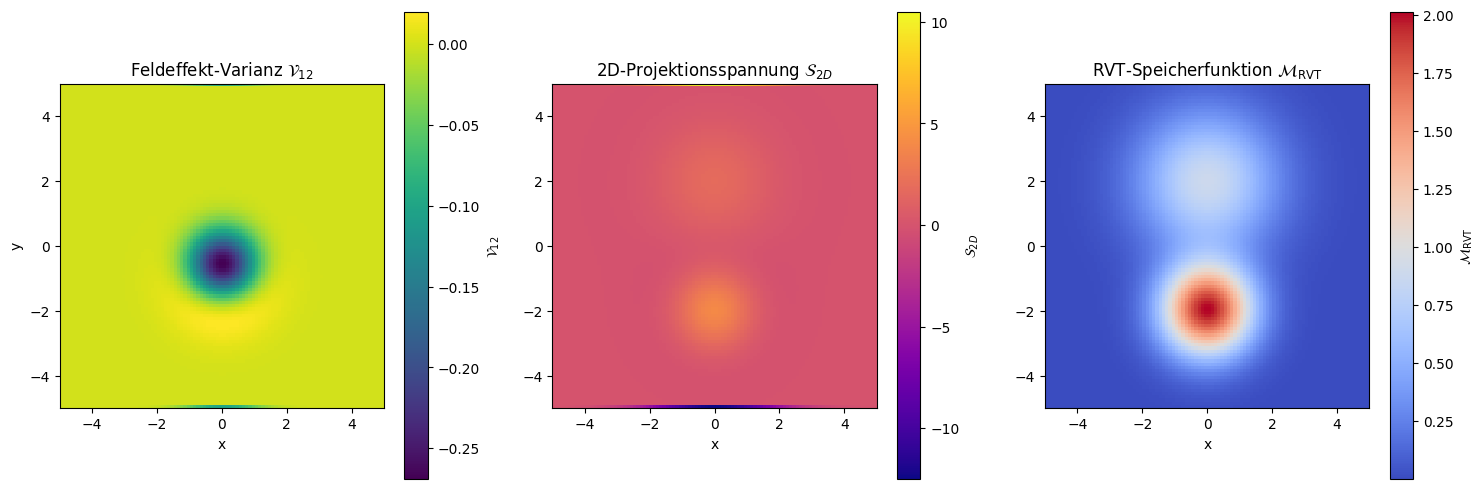

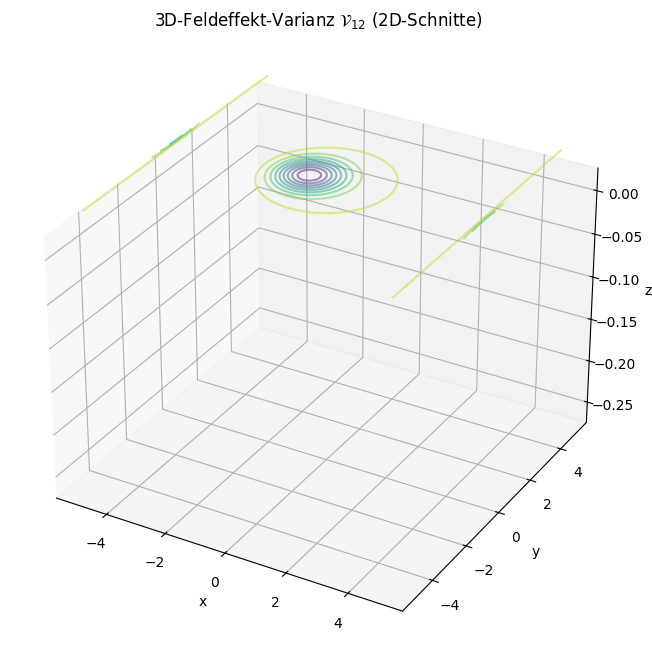

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import gaussian_filter

# --- Parameter ---
N = 100  # Gitterpunkte
L = 10.0  # Systemgröße
alpha = 0.8  # Kopplungskonstante (RVT)
chi = 1.0    # Kopplungskonstante für M_RVT

# --- Gitter erstellen ---
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z)

# --- Projektionsfelder Xi_1 und Xi_2 (Gauß'sche Verteilungen) ---
Xi_1 = np.exp(-((X + 2)**2 + Y**2 + Z**2) / (2 * 1.0**2))
Xi_2 = np.exp(-((X - 2)**2 + Y**2 + Z**2) / (2 * 1.5**2))
Xi = Xi_1 + Xi_2

# --- Gradienten berechnen (zentrale Differenzen) ---
def gradient(f, dx):
    grad_x = (np.roll(f, 1, axis=0) - np.roll(f, -1, axis=0)) / (2 * dx)
    grad_y = (np.roll(f, 1, axis=1) - np.roll(f, -1, axis=1)) / (2 * dx)
    grad_z = (np.roll(f, 1, axis=2) - np.roll(f, -1, axis=2)) / (2 * dx)
    return np.stack((grad_x, grad_y, grad_z), axis=-1)

dx = L / (N - 1)
grad_Xi_1 = gradient(Xi_1, dx)
grad_Xi_2 = gradient(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 (Kreuzterm) ---
V_12 = 2 * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)  # Skalarprodukt der Gradienten

# --- RVT-Korrekturtensor E_mu_nu (vereinfacht für 3D) ---
laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
             np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
             np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
             6 * Xi) / (dx**2)

E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

# --- Projektion auf 2D-Ebene (z.B. x-y-Ebene) ---
S_2D = E_xx + E_yy  # Spur in 2D (vereinfacht)
S_perp = E_zz        # Blockierter Normalanteil (z-Richtung)
M_RVT = S_2D - S_perp  # RVT-Speicherfunktion

# --- Visualisierung ---
# 2D-Schnitt bei z=0 (x-y-Ebene)
z_slice = N // 2
V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

# Plot 1: Feldeffekt-Varianz V_12
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(V_12_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='viridis')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(r'Feldeffekt-Varianz $\mathcal{V}_{12}$')
plt.xlabel('x')
plt.ylabel('y')

# Plot 2: 2D-Projektionsspannung S_2D
plt.subplot(1, 3, 2)
plt.imshow(S_2D_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='plasma')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x')

# Plot 3: RVT-Speicherfunktion M_RVT
plt.subplot(1, 3, 3)
plt.imshow(M_RVT_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='coolwarm')
plt.colorbar(label=r'$\mathcal{M}_{\text{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\text{RVT}}$')
plt.xlabel('x')

plt.tight_layout()
plt.savefig('RVT_Varianz_Simulation_2D.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz (Isosurface in 2D-Schnitten) ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Isosurface für V_12 in 2D-Schnitten (x-y, x-z, y-z)
for z_fix in [N//4, N//2, 3*N//4]:
    ax.contour(X[:, :, z_fix], Y[:, :, z_fix], V_12[:, :, z_fix],
               levels=10, cmap='viridis', alpha=0.5, zdir='z', offset=z[z_fix])

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$ (2D-Schnitte)')

plt.savefig('RVT_Varianz_3D_Schnitte.png', dpi=300)
plt.show()

# Neuer Abschnitt

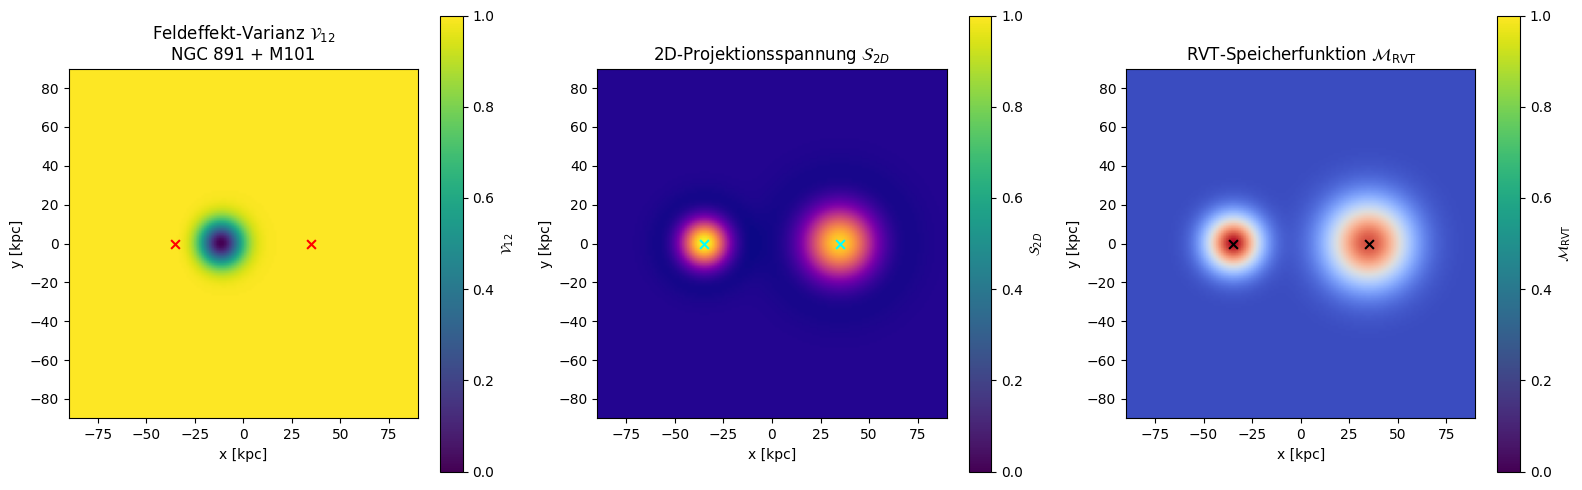

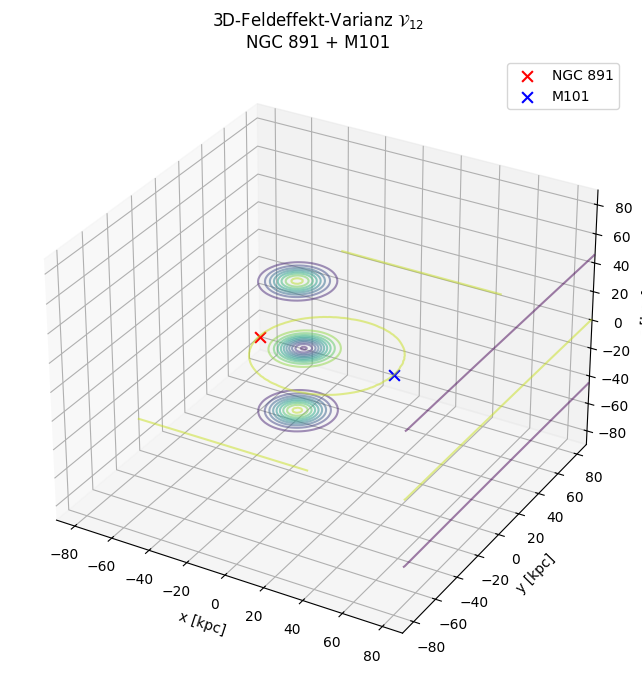

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# ZELLE 2: RVT-Feldeffekt-Varianz für NGC 891 + M101
# Ohne explizite Inklinationsskalierung
# ============================================================

# --- Parameter ---
N = 140          # Gitterpunkte; vorher 100
L = 180.0        # Systemgröße in kpc; Fenster: [-90, +90] kpc
alpha = 0.8      # RVT-Kopplungskonstante
chi = 1.0        # Kopplungskonstante für M_RVT

# --- Galaxienparameter ---
# NGC 891: Edge-on-Galaxie
M_891 = 5e10          # baryonische Masse in M_sun, Näherungswert
scale_891 = 10.0      # Skalenlänge in kpc
center_891 = (-35.0, 0.0, 0.0)

# M101: Face-on-Galaxie
M_M101 = 1e11         # baryonische Masse in M_sun, Näherungswert
scale_M101 = 15.0     # Skalenlänge in kpc
center_M101 = (35.0, 0.0, 0.0)

# --- Gitter erstellen ---
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)

dx = x[1] - x[0]

# Wichtig: indexing='ij', damit axis=0 -> x, axis=1 -> y, axis=2 -> z
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# --- Gaußförmige Projektionsfelder ---
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * scale**2)
    )

Xi_1 = gaussian_field(M_891, scale_891, center_891)
Xi_2 = gaussian_field(M_M101, scale_M101, center_M101)

Xi = Xi_1 + Xi_2

# --- Gradienten berechnen ---
def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

grad_Xi_1 = gradient_3d(Xi_1, dx)
grad_Xi_2 = gradient_3d(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 ---
V_12 = 2.0 * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

# --- Zweite Ableitungen / Laplace ---
def second_derivative(f, dx, axis):
    first = np.gradient(f, dx, axis=axis, edge_order=2)
    second = np.gradient(first, dx, axis=axis, edge_order=2)
    return second

d2x_Xi = second_derivative(Xi, dx, axis=0)
d2y_Xi = second_derivative(Xi, dx, axis=1)
d2z_Xi = second_derivative(Xi, dx, axis=2)

laplace_Xi = d2x_Xi + d2y_Xi + d2z_Xi

# --- RVT-Korrekturtensor E_mu_nu, 3D-vereinfachte Diagonalkomponenten ---
E_xx = d2x_Xi - laplace_Xi
E_yy = d2y_Xi - laplace_Xi
E_zz = d2z_Xi - laplace_Xi

# --- Projektion auf 2D-Ebene ---
S_2D = E_xx + E_yy
S_perp = E_zz
M_RVT = S_2D - S_perp

# --- 2D-Schnitt bei z = 0 ---
z_slice = N // 2

V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

# --- Visualisierung 2D ---
plt.figure(figsize=(16, 5))

# Plot 1: Feldeffekt-Varianz
plt.subplot(1, 3, 1)
plt.imshow(
    V_12_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='viridis',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='red', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(r'Feldeffekt-Varianz $\mathcal{V}_{12}$' + '\nNGC 891 + M101')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 2: 2D-Projektionsspannung
plt.subplot(1, 3, 2)
plt.imshow(
    S_2D_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='plasma',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='cyan', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 3: RVT-Speicherfunktion
plt.subplot(1, 3, 3)
plt.imshow(
    M_RVT_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='black', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{M}_{\mathrm{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\mathrm{RVT}}$')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

plt.tight_layout()
plt.savefig('RVT_Varianz_NGC891_M101_grid180.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz in mehreren z-Schnitten ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for z_fix in [N // 4, N // 2, 3 * N // 4]:
    ax.contour(
        X[:, :, z_fix],
        Y[:, :, z_fix],
        V_12[:, :, z_fix],
        levels=10,
        cmap='viridis',
        alpha=0.5,
        zdir='z',
        offset=z[z_fix]
    )

ax.scatter(center_891[0], center_891[1], center_891[2],
           c='red', s=60, marker='x', label='NGC 891')
ax.scatter(center_M101[0], center_M101[1], center_M101[2],
           c='blue', s=60, marker='x', label='M101')

ax.set_xlim(-L / 2, L / 2)
ax.set_ylim(-L / 2, L / 2)
ax.set_zlim(-L / 2, L / 2)

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_zlabel('z [kpc]')
ax.set_title(r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$' + '\nNGC 891 + M101')
ax.legend()

plt.savefig('RVT_Varianz_3D_NGC891_M101_grid180.png', dpi=300)
plt.show()


gamma_RVT(NGC 891, 85°) = 1.797
gamma_RVT(M101,    18°) = 1.247


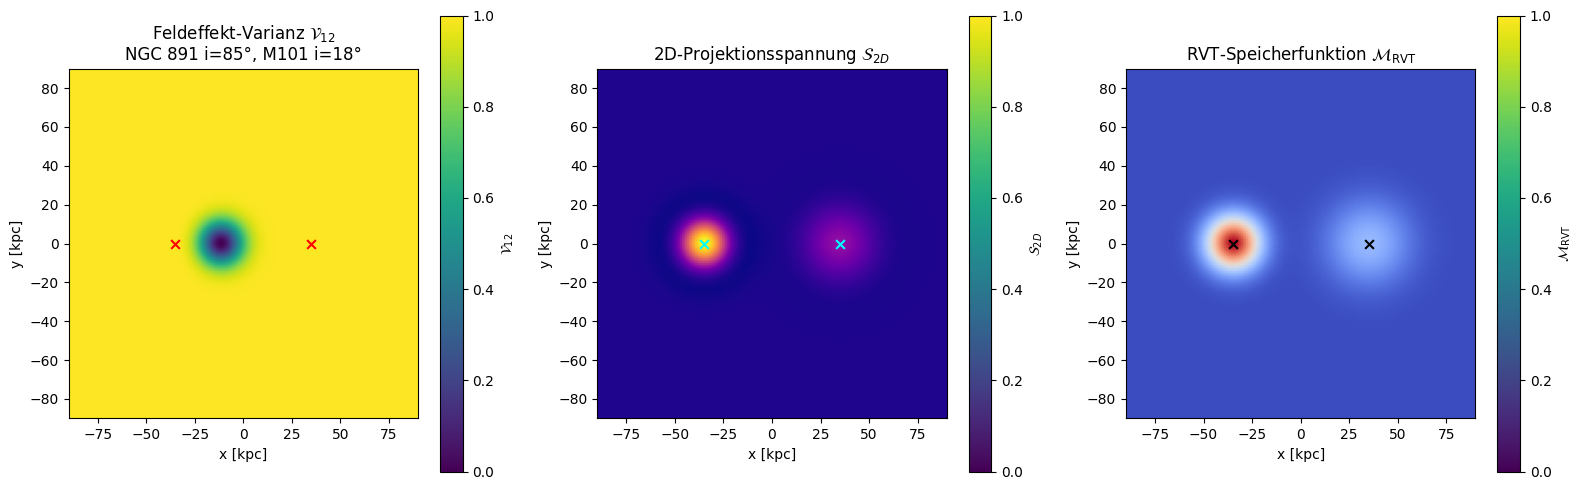

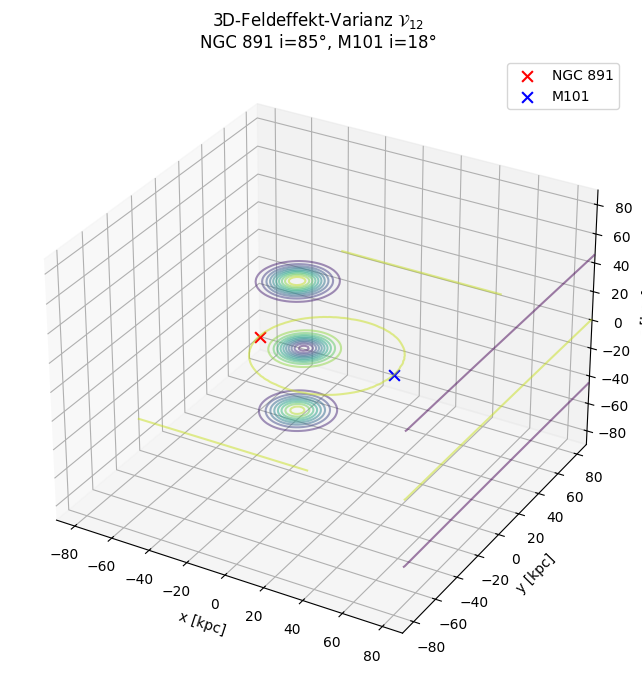

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# ZELLE 3: RVT-Feldeffekt-Varianz mit Inklinationsskalierung
# NGC 891: 85°
# M101:    18°
# ============================================================

# --- Parameter ---
N = 140           # Gitterpunkte; vorher 100
L = 180.0         # Systemgröße in kpc; Fenster: [-90, +90] kpc
C_RVT = 0.8       # RVT-Kopplungskonstante

# --- Galaxienparameter ---
M_891 = 5e10
scale_891 = 10.0
center_891 = (-35.0, 0.0, 0.0)

M_M101 = 1e11
scale_M101 = 15.0
center_M101 = (35.0, 0.0, 0.0)

# --- Inklinationswinkel ---
inclination_891_deg = 85.0
inclination_M101_deg = 18.0

inclination_891 = np.radians(inclination_891_deg)
inclination_M101 = np.radians(inclination_M101_deg)

# --- RVT-Gamma-Korrektur ---
gamma_891 = 1.0 + C_RVT * np.sin(inclination_891)
gamma_M101 = 1.0 + C_RVT * np.sin(inclination_M101)

print(f"gamma_RVT(NGC 891, {inclination_891_deg:.0f}°) = {gamma_891:.3f}")
print(f"gamma_RVT(M101,    {inclination_M101_deg:.0f}°) = {gamma_M101:.3f}")

# --- Gitter erstellen ---
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)

dx = x[1] - x[0]

# Wichtig: indexing='ij', damit axis=0 -> x, axis=1 -> y, axis=2 -> z
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# --- Gaußförmige Projektionsfelder mit Inklinationsskalierung ---
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * scale**2)
    )

# Originale Inklinationsprojektion:
# Feld wird mit sin(i) gewichtet.
Xi_1 = gaussian_field(M_891, scale_891, center_891) * np.sin(inclination_891)
Xi_2 = gaussian_field(M_M101, scale_M101, center_M101) * np.sin(inclination_M101)

Xi = Xi_1 + Xi_2

# --- Gradienten berechnen ---
def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

grad_Xi_1 = gradient_3d(Xi_1, dx)
grad_Xi_2 = gradient_3d(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 mit RVT-Kopplungsfaktor ---
V_12 = 2.0 * C_RVT * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

# --- Zweite Ableitungen / Laplace ---
def second_derivative(f, dx, axis):
    first = np.gradient(f, dx, axis=axis, edge_order=2)
    second = np.gradient(first, dx, axis=axis, edge_order=2)
    return second

d2x_Xi = second_derivative(Xi, dx, axis=0)
d2y_Xi = second_derivative(Xi, dx, axis=1)
d2z_Xi = second_derivative(Xi, dx, axis=2)

laplace_Xi = d2x_Xi + d2y_Xi + d2z_Xi

# --- RVT-Korrekturtensor E_mu_nu, 3D-vereinfachte Diagonalkomponenten ---
E_xx = d2x_Xi - laplace_Xi
E_yy = d2y_Xi - laplace_Xi
E_zz = d2z_Xi - laplace_Xi

# --- Projektion auf 2D-Ebene ---
S_2D = E_xx + E_yy
S_perp = E_zz
M_RVT = S_2D - S_perp

# --- 2D-Schnitt bei z = 0 ---
z_slice = N // 2

V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

# --- Visualisierung 2D ---
plt.figure(figsize=(16, 5))

# Plot 1: Feldeffekt-Varianz
plt.subplot(1, 3, 1)
plt.imshow(
    V_12_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='viridis',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='red', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(
    r'Feldeffekt-Varianz $\mathcal{V}_{12}$'
    + '\nNGC 891 i=85°, M101 i=18°'
)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 2: 2D-Projektionsspannung
plt.subplot(1, 3, 2)
plt.imshow(
    S_2D_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='plasma',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='cyan', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 3: RVT-Speicherfunktion
plt.subplot(1, 3, 3)
plt.imshow(
    M_RVT_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='black', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{M}_{\mathrm{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\mathrm{RVT}}$')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

plt.tight_layout()
plt.savefig('RVT_Varianz_Inklination_NGC891_M101_grid180.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz in mehreren z-Schnitten ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for z_fix in [N // 4, N // 2, 3 * N // 4]:
    ax.contour(
        X[:, :, z_fix],
        Y[:, :, z_fix],
        V_12[:, :, z_fix],
        levels=10,
        cmap='viridis',
        alpha=0.5,
        zdir='z',
        offset=z[z_fix]
    )

ax.scatter(center_891[0], center_891[1], center_891[2],
           c='red', s=60, marker='x', label='NGC 891')
ax.scatter(center_M101[0], center_M101[1], center_M101[2],
           c='blue', s=60, marker='x', label='M101')

ax.set_xlim(-L / 2, L / 2)
ax.set_ylim(-L / 2, L / 2)
ax.set_zlim(-L / 2, L / 2)

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_zlabel('z [kpc]')
ax.set_title(
    r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$'
    + '\nNGC 891 i=85°, M101 i=18°'
)
ax.legend()

plt.savefig('RVT_Varianz_3D_Inklination_NGC891_M101_grid180.png', dpi=300)
plt.show()


Zielausrichtung gamma_RVT(90°)      = 1.800
gamma_RVT(NGC 891, 85°)             = 1.797
gamma_RVT(M101, 18°)                = 1.247
relative Funnel-Amplitude Normal NGC 891 = 1.000
relative Funnel-Amplitude Normal M101    = 1.000
relative Funnel-Amplitude Incl NGC 891   = 0.998
relative Funnel-Amplitude Incl M101      = 0.693


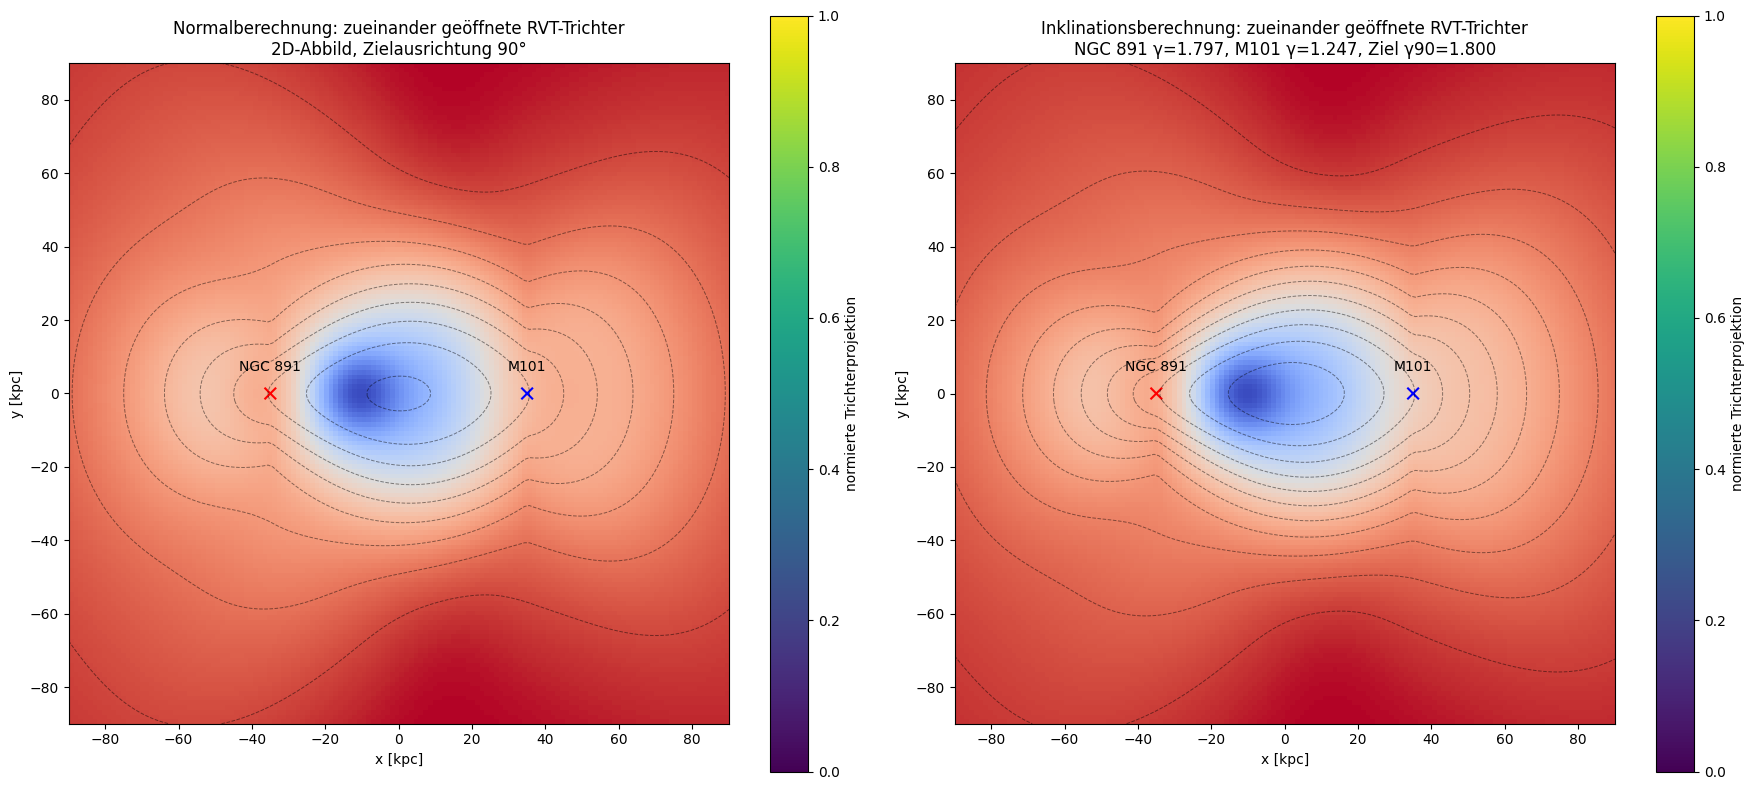

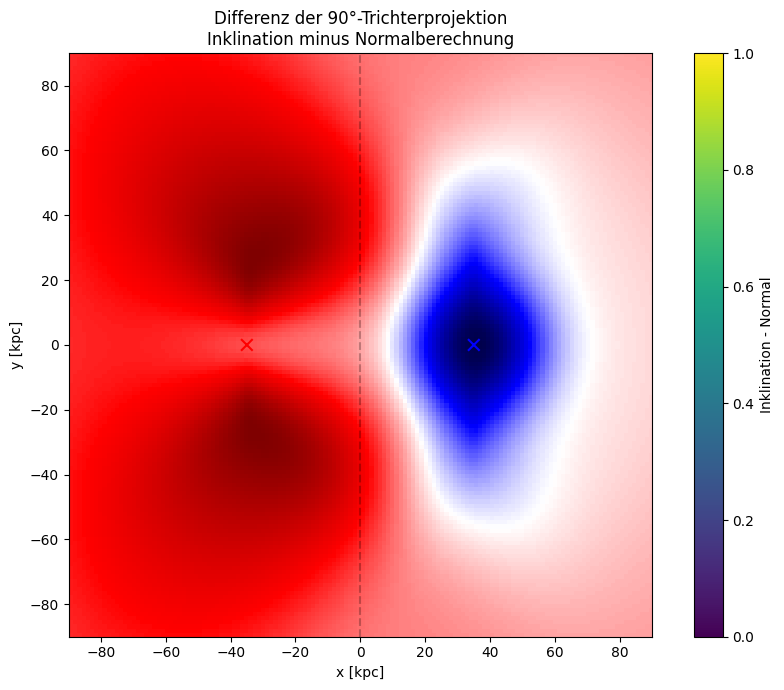

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ZELLE 4:
# Trichterförmige RVT-Projektionsfunktion
# Vergleich:
# 1. Normalberechnung
# 2. Inklinationsberechnung
#
# Ziel:
# Zwei zueinander geöffnete 2D-Trichter bei 90°-Ausrichtung
# ============================================================

# ------------------------------------------------------------
# Parameter
# ------------------------------------------------------------
N = 140
L = 180.0
C_RVT = 0.8

# Zielausrichtung: 90°
target_angle_deg = 90.0
target_angle = np.radians(target_angle_deg)
gamma_90 = 1.0 + C_RVT * np.sin(target_angle)

# Galaxienparameter
M_891 = 5e10
scale_891 = 10.0
center_891 = (-35.0, 0.0, 0.0)

M_M101 = 1e11
scale_M101 = 15.0
center_M101 = (35.0, 0.0, 0.0)

# Beobachtete Inklinationen
inclination_891_deg = 85.0
inclination_M101_deg = 18.0

inclination_891 = np.radians(inclination_891_deg)
inclination_M101 = np.radians(inclination_M101_deg)

gamma_891 = 1.0 + C_RVT * np.sin(inclination_891)
gamma_M101 = 1.0 + C_RVT * np.sin(inclination_M101)

print(f"Zielausrichtung gamma_RVT(90°)      = {gamma_90:.3f}")
print(f"gamma_RVT(NGC 891, 85°)             = {gamma_891:.3f}")
print(f"gamma_RVT(M101, 18°)                = {gamma_M101:.3f}")

# ------------------------------------------------------------
# Gitter
# ------------------------------------------------------------
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)

dx = x[1] - x[0]

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# ------------------------------------------------------------
# Basisfeld
# ------------------------------------------------------------
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * scale**2)
    )

def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

def second_derivative(f, dx, axis):
    first = np.gradient(f, dx, axis=axis, edge_order=2)
    second = np.gradient(first, dx, axis=axis, edge_order=2)
    return second

def compute_rvt_values(Xi_1, Xi_2, coupling=1.0):
    """
    Liefert V_12 und M_RVT für gegebene Felder.
    """
    Xi = Xi_1 + Xi_2

    grad_Xi_1 = gradient_3d(Xi_1, dx)
    grad_Xi_2 = gradient_3d(Xi_2, dx)

    V_12 = 2.0 * coupling * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

    d2x_Xi = second_derivative(Xi, dx, axis=0)
    d2y_Xi = second_derivative(Xi, dx, axis=1)
    d2z_Xi = second_derivative(Xi, dx, axis=2)

    laplace_Xi = d2x_Xi + d2y_Xi + d2z_Xi

    E_xx = d2x_Xi - laplace_Xi
    E_yy = d2y_Xi - laplace_Xi
    E_zz = d2z_Xi - laplace_Xi

    S_2D = E_xx + E_yy
    S_perp = E_zz
    M_RVT = S_2D - S_perp

    return V_12, M_RVT, S_2D, S_perp

# ------------------------------------------------------------
# Normalrechnung
# ------------------------------------------------------------
Xi_891_normal = gaussian_field(M_891, scale_891, center_891)
Xi_M101_normal = gaussian_field(M_M101, scale_M101, center_M101)

V_12_normal, M_RVT_normal, S_2D_normal, S_perp_normal = compute_rvt_values(
    Xi_891_normal,
    Xi_M101_normal,
    coupling=1.0
)

# ------------------------------------------------------------
# Inklinationsrechnung
# ------------------------------------------------------------
Xi_891_incl = gaussian_field(M_891, scale_891, center_891) * gamma_891
Xi_M101_incl = gaussian_field(M_M101, scale_M101, center_M101) * gamma_M101

V_12_incl, M_RVT_incl, S_2D_incl, S_perp_incl = compute_rvt_values(
    Xi_891_incl,
    Xi_M101_incl,
    coupling=C_RVT
)

# ------------------------------------------------------------
# 2D-Schnitt
# ------------------------------------------------------------
z_slice = N // 2

Vn = V_12_normal[:, :, z_slice]
Mn = M_RVT_normal[:, :, z_slice]

Vi = V_12_incl[:, :, z_slice]
Mi = M_RVT_incl[:, :, z_slice]

# ------------------------------------------------------------
# Trichterfunktion
# ------------------------------------------------------------
def opposing_funnel_2d(
    X2,
    Y2,
    center_left,
    center_right,
    amp_left,
    amp_right,
    width_left,
    width_right,
    length_scale,
    target_angle=np.pi / 2,
):
    """
    Erzeugt zwei zueinander geöffnete 2D-Trichter.

    Linker Trichter:
        Zentrum links, Öffnung nach rechts.

    Rechter Trichter:
        Zentrum rechts, Öffnung nach links.

    Die 90°-Ausrichtung wird als volle tangentiale Öffnung
    über sin(target_angle) eingebaut.
    """

    xL, yL = center_left
    xR, yR = center_right

    # Koordinaten relativ zu den Zentren
    XL = X2 - xL
    YL = Y2 - yL

    XR = X2 - xR
    YR = Y2 - yR

    # Öffnungsgewicht bei Zielwinkel 90°
    opening = np.sin(target_angle)

    # Linker Trichter öffnet nach rechts:
    # Nur Bereich x >= xL wird stark geöffnet.
    forward_L = 1.0 / (1.0 + np.exp(-XL / length_scale))

    # Rechter Trichter öffnet nach links:
    # Nur Bereich x <= xR wird stark geöffnet.
    forward_R = 1.0 / (1.0 + np.exp(XR / length_scale))

    # Radiale Trichterbreite wächst mit Entfernung vom Zentrum.
    # Dadurch entsteht die "aufgehende" Trichterform.
    radial_width_L = width_left * (1.0 + np.abs(XL) / length_scale)
    radial_width_R = width_right * (1.0 + np.abs(XR) / length_scale)

    # Trichterprofile
    funnel_L = (
        -amp_left
        * opening
        * forward_L
        * np.exp(-(YL**2) / (2.0 * radial_width_L**2))
        * np.exp(-(XL**2) / (2.0 * (2.5 * length_scale)**2))
    )

    funnel_R = (
        -amp_right
        * opening
        * forward_R
        * np.exp(-(YR**2) / (2.0 * radial_width_R**2))
        * np.exp(-(XR**2) / (2.0 * (2.5 * length_scale)**2))
    )

    # Gesamttrichter: beide öffnen zueinander
    funnel_total = funnel_L + funnel_R

    return funnel_total, funnel_L, funnel_R

# ------------------------------------------------------------
# 2D-Gitter für Trichter
# ------------------------------------------------------------
X2 = X[:, :, z_slice]
Y2 = Y[:, :, z_slice]

center_891_2d = (center_891[0], center_891[1])
center_M101_2d = (center_M101[0], center_M101[1])

# ------------------------------------------------------------
# Amplituden aus den berechneten RVT-Werten ableiten
# ------------------------------------------------------------
def robust_amp(A):
    """
    Robuste Amplitude:
    nimmt 99%-Perzentil statt Maximum,
    damit einzelne numerische Spitzen nicht alles dominieren.
    """
    return np.percentile(np.abs(A), 99)

amp_normal = robust_amp(Vn) + robust_amp(Mn)
amp_incl = robust_amp(Vi) + robust_amp(Mi)

# Normierung für saubere Darstellung
amp_normal = amp_normal / (amp_normal + 1e-30)
amp_incl = amp_incl / (amp_incl + 1e-30)

# Relative RVT-Skalierung
# Normalfall: beide Trichter gleich aus der Feldamplitude.
amp_891_normal = amp_normal
amp_M101_normal = amp_normal

# Inklinationsfall:
# auf 90°-Zielausrichtung bezogen.
amp_891_incl = amp_incl * (gamma_891 / gamma_90)
amp_M101_incl = amp_incl * (gamma_M101 / gamma_90)

print(f"relative Funnel-Amplitude Normal NGC 891 = {amp_891_normal:.3f}")
print(f"relative Funnel-Amplitude Normal M101    = {amp_M101_normal:.3f}")
print(f"relative Funnel-Amplitude Incl NGC 891   = {amp_891_incl:.3f}")
print(f"relative Funnel-Amplitude Incl M101      = {amp_M101_incl:.3f}")

# ------------------------------------------------------------
# Trichter erzeugen
# ------------------------------------------------------------
width_891 = scale_891
width_M101 = scale_M101
length_scale = 28.0

funnel_normal, funnel_891_normal, funnel_M101_normal = opposing_funnel_2d(
    X2,
    Y2,
    center_891_2d,
    center_M101_2d,
    amp_891_normal,
    amp_M101_normal,
    width_891,
    width_M101,
    length_scale,
    target_angle=target_angle,
)

funnel_incl, funnel_891_incl, funnel_M101_incl = opposing_funnel_2d(
    X2,
    Y2,
    center_891_2d,
    center_M101_2d,
    amp_891_incl,
    amp_M101_incl,
    width_891,
    width_M101,
    length_scale,
    target_angle=target_angle,
)

# ------------------------------------------------------------
# Kombinierte Karten:
# Trichter wird mit V_12 + M_RVT gekoppelt.
# ------------------------------------------------------------
def normalize(A):
    return A / (np.max(np.abs(A)) + 1e-30)

normal_background = normalize(Vn) + normalize(Mn)
incl_background = normalize(Vi) + normalize(Mi)

normal_projection = normalize(funnel_normal) + 0.35 * normalize(normal_background)
incl_projection = normalize(funnel_incl) + 0.35 * normalize(incl_background)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(18, 8))

# Normaltrichter
plt.subplot(1, 2, 1)
plt.imshow(
    normal_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.contour(
    X2,
    Y2,
    funnel_normal,
    levels=12,
    colors='black',
    alpha=0.45,
    linewidths=0.7
)
plt.scatter(
    [center_891[0], center_M101[0]],
    [center_891[1], center_M101[1]],
    c=['red', 'blue'],
    s=70,
    marker='x'
)
plt.text(center_891[0], center_891[1] + 6, 'NGC 891', color='black', ha='center')
plt.text(center_M101[0], center_M101[1] + 6, 'M101', color='black', ha='center')
plt.colorbar(label='normierte Trichterprojektion')
plt.title(
    'Normalberechnung: zueinander geöffnete RVT-Trichter\n'
    '2D-Abbild, Zielausrichtung 90°'
)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Inklinationstrichter
plt.subplot(1, 2, 2)
plt.imshow(
    incl_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.contour(
    X2,
    Y2,
    funnel_incl,
    levels=12,
    colors='black',
    alpha=0.45,
    linewidths=0.7
)
plt.scatter(
    [center_891[0], center_M101[0]],
    [center_891[1], center_M101[1]],
    c=['red', 'blue'],
    s=70,
    marker='x'
)
plt.text(center_891[0], center_891[1] + 6, 'NGC 891', color='black', ha='center')
plt.text(center_M101[0], center_M101[1] + 6, 'M101', color='black', ha='center')
plt.colorbar(label='normierte Trichterprojektion')
plt.title(
    'Inklinationsberechnung: zueinander geöffnete RVT-Trichter\n'
    f'NGC 891 γ={gamma_891:.3f}, M101 γ={gamma_M101:.3f}, Ziel γ90={gamma_90:.3f}'
)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

plt.tight_layout()
plt.savefig('RVT_Trichter_90deg_Normal_vs_Inklination_NGC891_M101.png', dpi=300)
plt.show()

# ------------------------------------------------------------
# Differenzkarte
# ------------------------------------------------------------
difference_projection = incl_projection - normal_projection

plt.figure(figsize=(9, 7))
plt.imshow(
    difference_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='seismic',
    aspect='equal'
)
plt.scatter(
    [center_891[0], center_M101[0]],
    [center_891[1], center_M101[1]],
    c=['red', 'blue'],
    s=70,
    marker='x'
)
plt.axvline(0, color='black', alpha=0.25, linestyle='--')
plt.colorbar(label='Inklination - Normal')
plt.title(
    'Differenz der 90°-Trichterprojektion\n'
    'Inklination minus Normalberechnung'
)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.tight_layout()
plt.savefig('RVT_Trichter_90deg_Differenz_NGC891_M101.png', dpi=300)
plt.show()


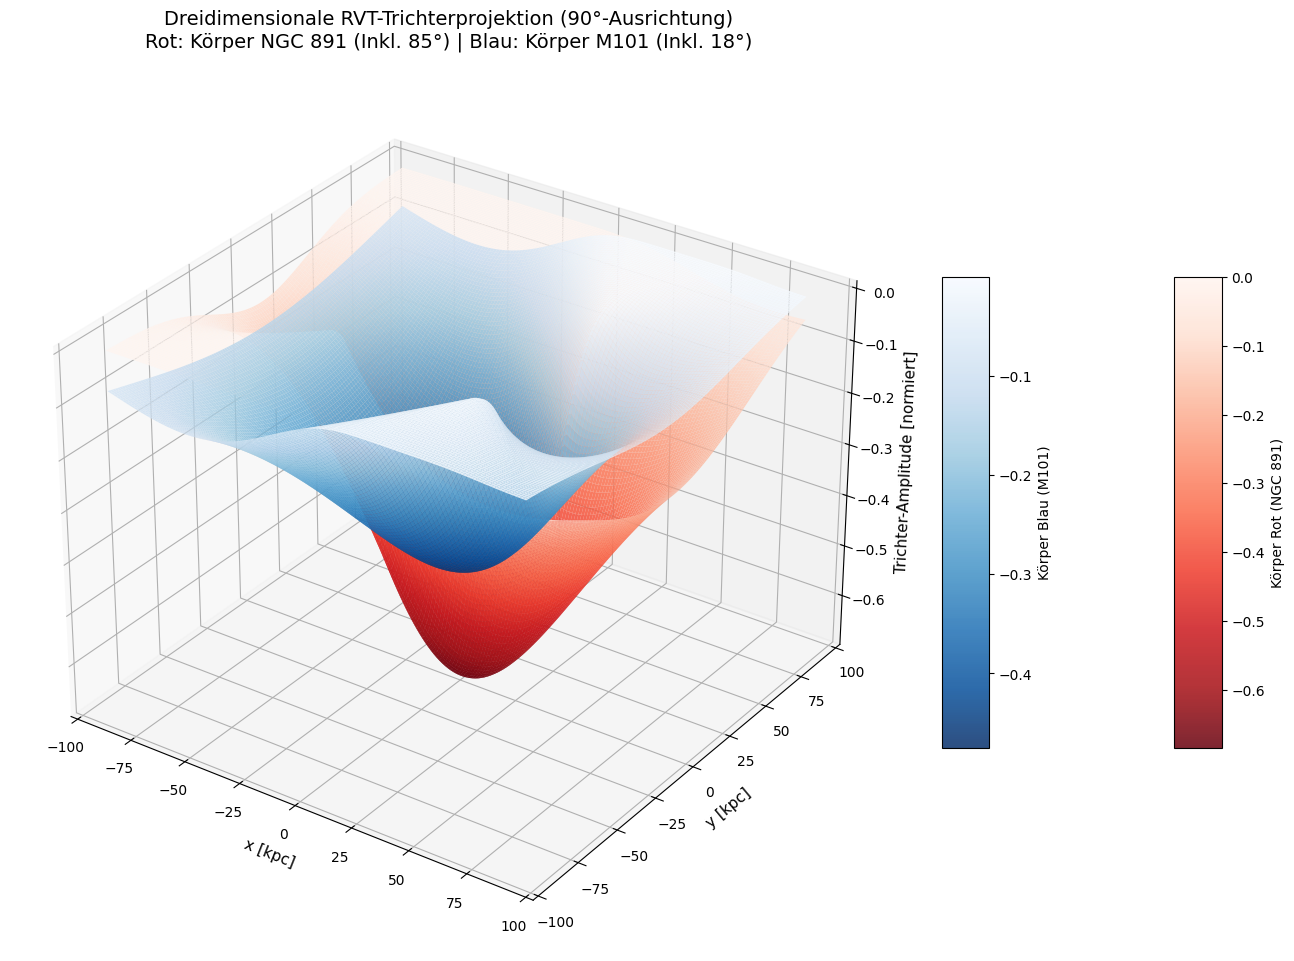

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ============================================================
# DREIDIMENSIONALE RVT-TRICHTER-PROJEKTION (ZELLE 4 ERWEITERT)
# ROTER KÖRPER (NGC 891) vs. BLAUER KÖRPER (M101)
# ============================================================

# Parameter (analog zu Zelle 4)
N = 140
L = 180.0
C_RVT = 0.8
target_angle_deg = 90.0
target_angle = np.radians(target_angle_deg)
length_scale = 28.0

# Galaxien-Zentren (2D-Ebene für den Trichter-Plot)
center_891_2d = (-35.0, 0.0)
center_M101_2d = (35.0, 0.0)

scale_891 = 10.0
scale_M101 = 15.0

# Inklinationsfaktoren aus deinen Berechnungen übernommen
gamma_891 = 1.0 + C_RVT * np.sin(np.radians(85.0))
gamma_M101 = 1.0 + C_RVT * np.sin(np.radians(18.0))
gamma_90 = 1.0 + C_RVT * np.sin(target_angle)

# Amplituden-Skalierung (basierend auf deinen RVT-Werten)
# Zur sauberen 3D-Darstellung normiert
amp_incl = 1.0
amp_891_incl = amp_incl * (gamma_891 / gamma_90)
amp_M101_incl = amp_incl * (gamma_M101 / gamma_90)

# Gitter für die 2D-Grundfläche (Z-Ebene aufgeweitet als Z_val Amplitude)
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
X2, Y2 = np.meshgrid(x, y, indexing='ij')

# ------------------------------------------------------------
# Getrennte Trichterberechnung für die Körper
# ------------------------------------------------------------
def compute_single_funnels(X2, Y2):
    xL, yL = center_891_2d
    xR, yR = center_M101_2d

    XL = X2 - xL
    YL = Y2 - yL
    XR = X2 - xR
    YR = Y2 - yR

    opening = np.sin(target_angle)

    # Flussrichtungen
    forward_L = 1.0 / (1.0 + np.exp(-XL / length_scale))
    forward_R = 1.0 / (1.0 + np.exp(XR / length_scale))

    # Breitenwachstum
    radial_width_L = scale_891 * (1.0 + np.abs(XL) / length_scale)
    radial_width_R = scale_M101 * (1.0 + np.abs(XR) / length_scale)

    # Linker Körper (NGC 891) - Rot
    funnel_L = (
        -amp_891_incl
        * opening
        * forward_L
        * np.exp(-(YL**2) / (2.0 * radial_width_L**2))
        * np.exp(-(XL**2) / (2.0 * (2.5 * length_scale)**2))
    )

    # Rechter Körper (M101) - Blau
    funnel_R = (
        -amp_M101_incl
        * opening
        * forward_R
        * np.exp(-(YR**2) / (2.0 * radial_width_R**2))
        * np.exp(-(XR**2) / (2.0 * (2.5 * length_scale)**2))
    )

    return funnel_L, funnel_R

funnel_red, funnel_blue = compute_single_funnels(X2, Y2)

# ------------------------------------------------------------
# 3D Plot-Erstellung
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# 1. Roter Körper: NGC 891 (Linker Trichter)
# Wir nutzen eine rote Farbkarte (Reds), um die Tiefe hervorzuheben
surf_red = ax.plot_surface(
    X2, Y2, funnel_red,
    cmap=cm.Reds_r,
    linewidth=0,
    antialiased=True,
    alpha=0.85,
    rcount=N, ccount=N
)

# 2. Blauer Körper: M101 (Rechter Trichter)
# Wir nutzen eine blaue Farbkarte (Blues)
surf_blue = ax.plot_surface(
    X2, Y2, funnel_blue,
    cmap=cm.Blues_r,
    linewidth=0,
    antialiased=True,
    alpha=0.85,
    rcount=N, ccount=N
)

# Design und Achsenbeschriftung
ax.set_title(
    'Dreidimensionale RVT-Trichterprojektion (90°-Ausrichtung)\n'
    'Rot: Körper NGC 891 (Inkl. 85°) | Blau: Körper M101 (Inkl. 18°)',
    fontsize=14, pad=20
)
ax.set_xlabel('x [kpc]', fontsize=11)
ax.set_ylabel('y [kpc]', fontsize=11)
ax.set_zlabel('Trichter-Amplitude [normiert]', fontsize=11)

# Ansichtswinkel optimieren, um die Trichteröffnung perfekt zu sehen
ax.view_init(elev=30, azim=-55)

# Farbbalken zur Orientierung hinzufügen
fig.colorbar(surf_red, ax=ax, shrink=0.5, aspect=10, label='Körper Rot (NGC 891)')
fig.colorbar(surf_blue, ax=ax, shrink=0.5, aspect=10, label='Körper Blau (M101)')

plt.tight_layout()
plt.savefig('RVT_3D_Trichter_Koerper_Rot_Blau.png', dpi=300)
plt.show()

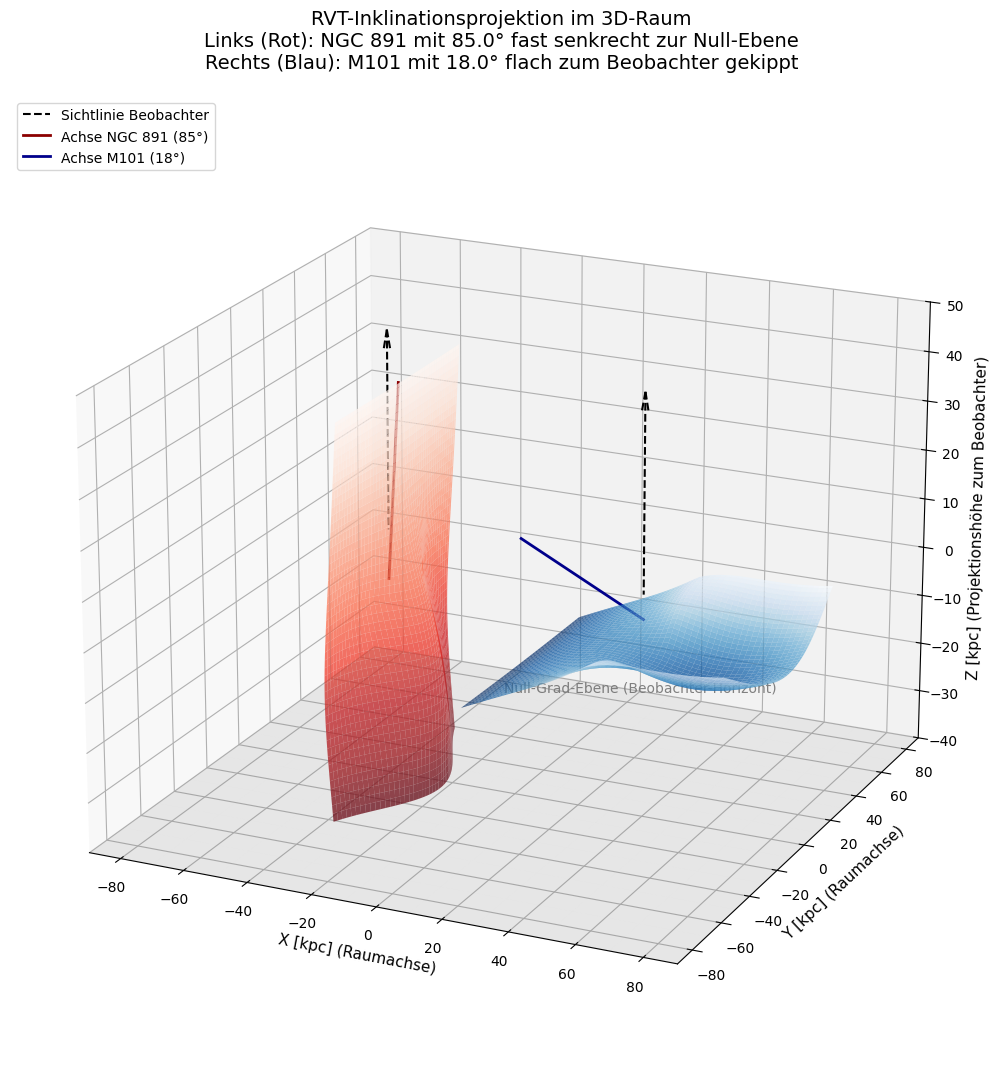

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ============================================================
# 3D-RVT-PROJEKTION: INKLINATIONSAUSRICHTUNG ZUM BEOBACHTER
# Rot: NGC 891 (85° geneigt, fast Edge-On zum Beobachter)
# Blau: M101 (18° geneigt, fast Face-On zum Beobachter)
# ============================================================

N = 100
L = 180.0
length_scale = 28.0

# Neigungswinkel zum Beobachter (Null-Grad-Ebene bei z=0)
inc_891_deg = 85.0
inc_M101_deg = 18.0

rad_891 = np.radians(inc_891_deg)
rad_M101 = np.radians(inc_M101_deg)

# Zentren der Körper auf der x-Achse
x_891 = -40.0
x_M101 = 40.0

# Lokales Gitter für die Trichtererzeugung (vor Rotation)
u = np.linspace(-40, 40, N)
v = np.linspace(-40, 40, N)
U, V = np.meshgrid(u, v, indexing='ij')

# ------------------------------------------------------------
# Mathematische Trichtergeometrie (lokales System)
# ------------------------------------------------------------
def local_funnel(U, V, scale, amp):
    # Öffnung entlang der lokalen U-Achse
    forward = 1.0 / (1.0 + np.exp(U / 10.0))
    radial_width = scale * (1.0 + np.abs(U) / length_scale)
    return -amp * forward * np.exp(-(V**2) / (2.0 * radial_width**2))

# Erzeuge die lokalen Amplitudenprofile
Z_891_local = local_funnel(U, V, scale=10.0, amp=20.0)
Z_M101_local = local_funnel(-U, V, scale=15.0, amp=20.0) # Entgegengesetzte Öffnung

# ------------------------------------------------------------
# 3D-Rotation und Projektion auf die Beobachter-Ebene
# ------------------------------------------------------------
# Rotationsmatrix um die Y-Achse (Inklination zum Beobachter)
def rotate_galaxy(U, V, Z_local, angle_rad, x_offset):
    # Rotationsformel für die Neigung gegen die z-Ebene
    X_rot = U * np.cos(angle_rad) - Z_local * np.sin(angle_rad) + x_offset
    Y_rot = V
    Z_rot = U * np.sin(angle_rad) + Z_local * np.cos(angle_rad)
    return X_rot, Y_rot, Z_rot

X_891, Y_891, Z_891 = rotate_galaxy(U, V, Z_891_local, rad_891, x_891)
X_M101, Y_M101, Z_M101 = rotate_galaxy(U, V, Z_M101_local, rad_M101, x_M101)

# ------------------------------------------------------------
# 3D-Szenen-Aufbau
# ------------------------------------------------------------
fig = plt.figure(figsize=(16, 11))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# 1. Null-Grad-Ebene des Beobachters (Referenzfläche bei z = -30 für bessere Sichtbarkeit)
z_floor = -40
x_floor = np.linspace(-L/2, L/2, 10)
y_floor = np.linspace(-L/2, L/2, 10)
X_f, Y_f = np.meshgrid(x_floor, y_floor)
ax.plot_surface(X_f, Y_f, np.full_like(X_f, z_floor), alpha=0.1, color='gray')
ax.text(0, L/2, z_floor, "Null-Grad-Ebene (Beobachter-Horizont)", color='gray', ha='center')

# 2. Roter Körper (NGC 891) - Stark aufgerichtet (85°)
surf_red = ax.plot_surface(
    X_891, Y_891, Z_891,
    cmap=cm.Reds_r, linewidth=0, antialiased=True, alpha=0.75
)

# 3. Blauer Körper (M101) - Flach geneigt (18°)
surf_blue = ax.plot_surface(
    X_M101, Y_M101, Z_M101,
    cmap=cm.Blues_r, linewidth=0, antialiased=True, alpha=0.75
)

# 4. Projektionspfeile / Sichtlinien zum Beobachter (Vektoren orthogonal zur Bildebene)
# Exemplarische Linien von den Zentren nach oben, um den Blickwinkel zu demonstrieren
ax.quiver([x_891, x_M101], [0, 0], [10, 5], [0, 0], [0, 0], [40, 40],
          color='black', linestyle='--', linewidth=1.5, arrow_length_ratio=0.1, label='Sichtlinie Beobachter')

# Symmetrie-Achsen der Körper einzeichnen
ax.plot([x_891, x_891 + 40 * np.cos(rad_891)], [0, 0], [0, 40 * np.sin(rad_891)], color='darkred', lw=2, label='Achse NGC 891 (85°)')
ax.plot([x_M101, x_M101 - 40 * np.cos(rad_M101)], [0, 0], [0, 40 * np.sin(rad_M101)], color='darkblue', lw=2, label='Achse M101 (18°)')

# Achsen-Konfiguration
ax.set_title(
    f'RVT-Inklinationsprojektion im 3D-Raum\n'
    f'Links (Rot): NGC 891 mit {inc_891_deg}° fast senkrecht zur Null-Ebene\n'
    f'Rechts (Blau): M101 mit {inc_M101_deg}° flach zum Beobachter gekippt',
    fontsize=14, pad=20
)
ax.set_xlabel('X [kpc] (Raumachse)', fontsize=11)
ax.set_ylabel('Y [kpc] (Raumachse)', fontsize=11)
ax.set_zlabel('Z [kpc] (Projektionshöhe zum Beobachter)', fontsize=11)

# Kameraposition so wählen, dass man die Neigung perfekt von der Seite/oben einsehen kann
ax.view_init(elev=20, azim=-65)

ax.set_xlim(-L/2, L/2)
ax.set_ylim(-L/2, L/2)
ax.set_zlim(z_floor, 50)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('RVT_3D_Inklinations_Projektion_Beobachter.png', dpi=300)
plt.show()

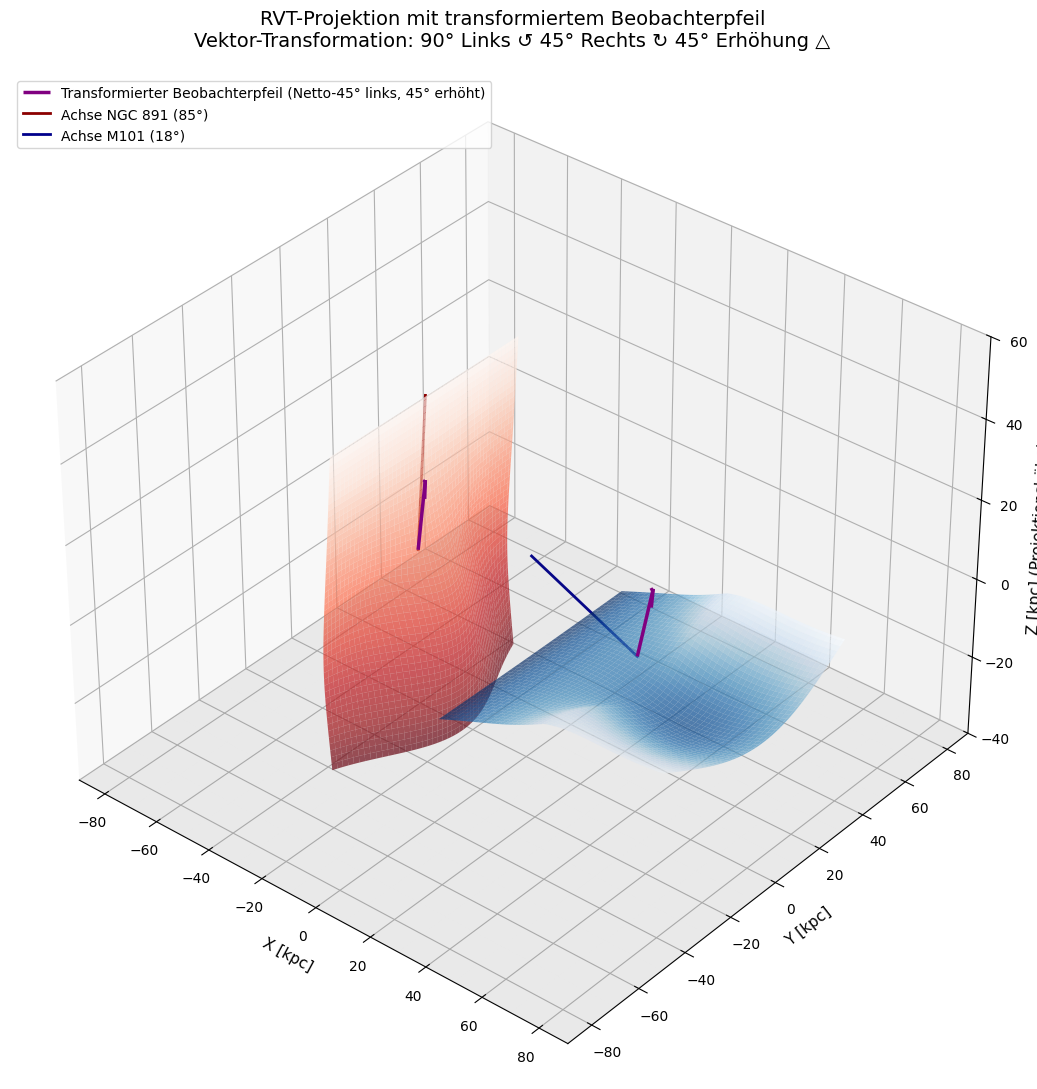

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ============================================================
# 3D-RVT-PROJEKTION: TRANSFORMIERTER BEOBACHTERPFEIL
# Rotation: 90° links -> 45° rechts -> 45° Elevation (Erhöhung)
# ============================================================

N = 100
L = 180.0
length_scale = 28.0

# Neigungswinkel der Galaxien (analog zu vorher)
inc_891_deg = 85.0
inc_M101_deg = 18.0
rad_891 = np.radians(inc_891_deg)
rad_M101 = np.radians(inc_M101_deg)

x_891, x_M101 = -40.0, 40.0

u = np.linspace(-40, 40, N)
v = np.linspace(-40, 40, N)
U, V = np.meshgrid(u, v, indexing='ij')

def local_funnel(U, V, scale, amp):
    forward = 1.0 / (1.0 + np.exp(U / 10.0))
    radial_width = scale * (1.0 + np.abs(U) / length_scale)
    return -amp * forward * np.exp(-(V**2) / (2.0 * radial_width**2))

Z_891_local = local_funnel(U, V, scale=10.0, amp=20.0)
Z_M101_local = local_funnel(-U, V, scale=15.0, amp=20.0)

def rotate_galaxy(U, V, Z_local, angle_rad, x_offset):
    X_rot = U * np.cos(angle_rad) - Z_local * np.sin(angle_rad) + x_offset
    Y_rot = V
    Z_rot = U * np.sin(angle_rad) + Z_local * np.cos(angle_rad)
    return X_rot, Y_rot, Z_rot

X_891, Y_891, Z_891 = rotate_galaxy(U, V, Z_891_local, rad_891, x_891)
X_M101, Y_M101, Z_M101 = rotate_galaxy(U, V, Z_M101_local, rad_M101, x_M101)

# ------------------------------------------------------------
# Berechnung des transformierten Beobachterpfeils
# ------------------------------------------------------------
# Ursprünglicher Blickvektor war rein in Z-Richtung: (0, 0, 1)
# 1. 90° links + 45° rechts = -45° im Azimut (XY-Ebene)
# 2. 45° Erhöhung (Elevation) in Z-Richtung
azimuth_rad = np.radians(-45)  # Netto-Drehung links
elevation_rad = np.radians(45) # Erhöhung

# Einheitsvektor des neuen Beobachters konstruieren
dx_obs = np.cos(elevation_rad) * np.cos(azimuth_rad)
dy_obs = np.cos(elevation_rad) * np.sin(azimuth_rad)
dz_obs = np.sin(elevation_rad)

# Skalierung für die Visualisierungslänge der Pfeile
arrow_scale = 50.0
dx_obs *= arrow_scale
dy_obs *= arrow_scale
dz_obs *= arrow_scale

# ------------------------------------------------------------
# 3D-Plot Setup
# ------------------------------------------------------------
fig = plt.figure(figsize=(16, 11))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# Horizontale Bezugsebene (Null-Grad)
z_floor = -40
x_floor = np.linspace(-L/2, L/2, 10)
y_floor = np.linspace(-L/2, L/2, 10)
X_f, Y_f = np.meshgrid(x_floor, y_floor)
ax.plot_surface(X_f, Y_f, np.full_like(X_f, z_floor), alpha=0.08, color='gray')

# Körper zeichnen
ax.plot_surface(X_891, Y_891, Z_891, cmap=cm.Reds_r, linewidth=0, antialiased=True, alpha=0.7)
ax.plot_surface(X_M101, Y_M101, Z_M101, cmap=cm.Blues_r, linewidth=0, antialiased=True, alpha=0.7)

# DIE TRANSFORMIERTEN BEOBACHTERPFEILE (Neue Sichtlinien)
# Wir setzen die Pfeile an den Galaxienzentren an und lassen sie in Richtung des transformierten Beobachters zeigen
ax.quiver(
    [x_891, x_M101], [0, 0], [0, 0],
    [dx_obs, dx_obs], [dy_obs, dy_obs], [dz_obs, dz_obs],
    color='purple', linestyle='-', linewidth=2.5, arrow_length_ratio=0.15,
    label='Transformierter Beobachterpfeil (Netto-45° links, 45° erhöht)'
)

# Symmetrie-Achsen der Galaxien (als Orientierungsstütze)
ax.plot([x_891, x_891 + 40 * np.cos(rad_891)], [0, 0], [0, 40 * np.sin(rad_891)], color='darkred', lw=2, label='Achse NGC 891 (85°)')
ax.plot([x_M101, x_M101 - 40 * np.cos(rad_M101)], [0, 0], [0, 40 * np.sin(rad_M101)], color='darkblue', lw=2, label='Achse M101 (18°)')

# Achsenbeschriftungen und Titel
ax.set_title(
    'RVT-Projektion mit transformiertem Beobachterpfeil\n'
    'Vektor-Transformation: 90° Links ↺ 45° Rechts ↻ 45° Erhöhung △',
    fontsize=14, pad=20
)
ax.set_xlabel('X [kpc]', fontsize=11)
ax.set_ylabel('Y [kpc]', fontsize=11)
ax.set_zlabel('Z [kpc] (Projektionshöhe)', fontsize=11)

# Kamera anpassen, um der neuen Beobachterachse orthogonal zu folgen (perfekte Einsicht)
ax.view_init(elev=35, azim=-50)

ax.set_xlim(-L/2, L/2)
ax.set_ylim(-L/2, L/2)
ax.set_zlim(z_floor, 60)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('RVT_3D_Beobachterpfeil_Transformiert.png', dpi=300)
plt.show()

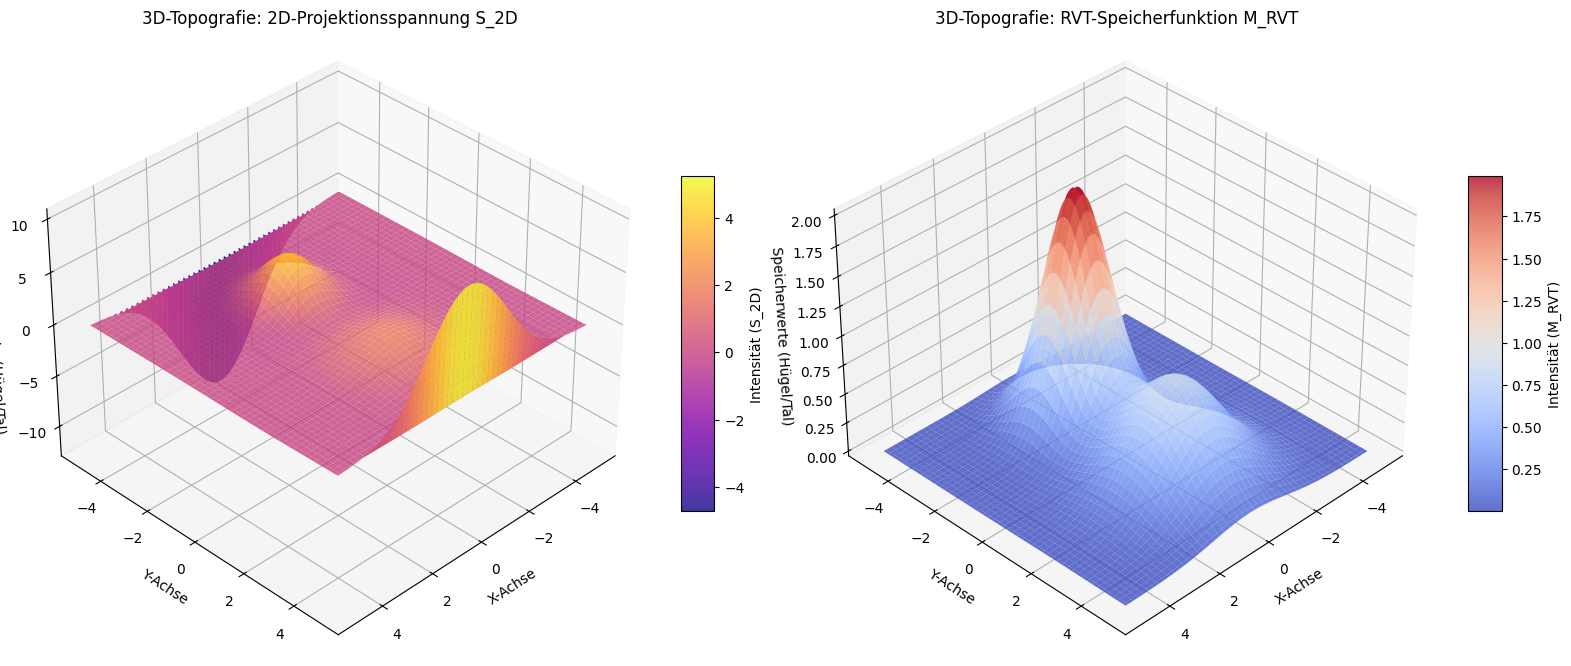

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Parameter ---
N = 100  # Gitterpunkte
L = 10.0  # Systemgröße

# --- Gitter erstellen ---
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z)

# --- Projektionsfelder Xi_1 und Xi_2 ---
Xi_1 = np.exp(-((X + 2)**2 + Y**2 + Z**2) / (2 * 1.0**2))
Xi_2 = np.exp(-((X - 2)**2 + Y**2 + Z**2) / (2 * 1.5**2))
Xi = Xi_1 + Xi_2

# --- RVT-Korrekturtensor E_mu_nu berechnen ---
dx = L / (N - 1)
laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
             np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
             np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
             6 * Xi) / (dx**2)

E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

# --- Projektion auf 2D-Ebene ---
S_2D = E_xx + E_yy  # Spur in 2D (vereinfacht)
S_perp = E_zz        # Blockierter Normalanteil (z-Richtung)
M_RVT = S_2D - S_perp  # RVT-Speicherfunktion

# --- 2D-Schnitt bei z=0 (x-y-Ebene) extrahieren ---
z_slice = N // 2
S_2D_slice = S_2D[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]

# Für plot_surface wird ein 2D-Meshgrid der X- und Y-Achse benötigt
X_2D, Y_2D = np.meshgrid(x, y)

# --- 3D-Oberflächen-Visualisierung (Hügel & Täler) ---
fig = plt.figure(figsize=(16, 7))

# Plot 1: 2D-Projektionsspannung S_2D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X_2D, Y_2D, S_2D_slice.T, cmap='plasma', edgecolor='none', alpha=0.8)
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='Intensität (S_2D)')
ax1.set_title('3D-Topografie: 2D-Projektionsspannung S_2D')
ax1.set_xlabel('X-Achse')
ax1.set_ylabel('Y-Achse')
ax1.set_zlabel('Spannungswerte (Hügel/Tal)')

# Plot 2: RVT-Speicherfunktion M_RVT
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X_2D, Y_2D, M_RVT_slice.T, cmap='coolwarm', edgecolor='none', alpha=0.8)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='Intensität (M_RVT)')
ax2.set_title('3D-Topografie: RVT-Speicherfunktion M_RVT')
ax2.set_xlabel('X-Achse')
ax2.set_ylabel('Y-Achse')
ax2.set_zlabel('Speicherwerte (Hügel/Tal)')

# Kameraperspektive leicht anpassen für bessere Sicht auf die Täler
ax1.view_init(elev=35, azim=45)
ax2.view_init(elev=35, azim=45)

plt.tight_layout()
plt.show()

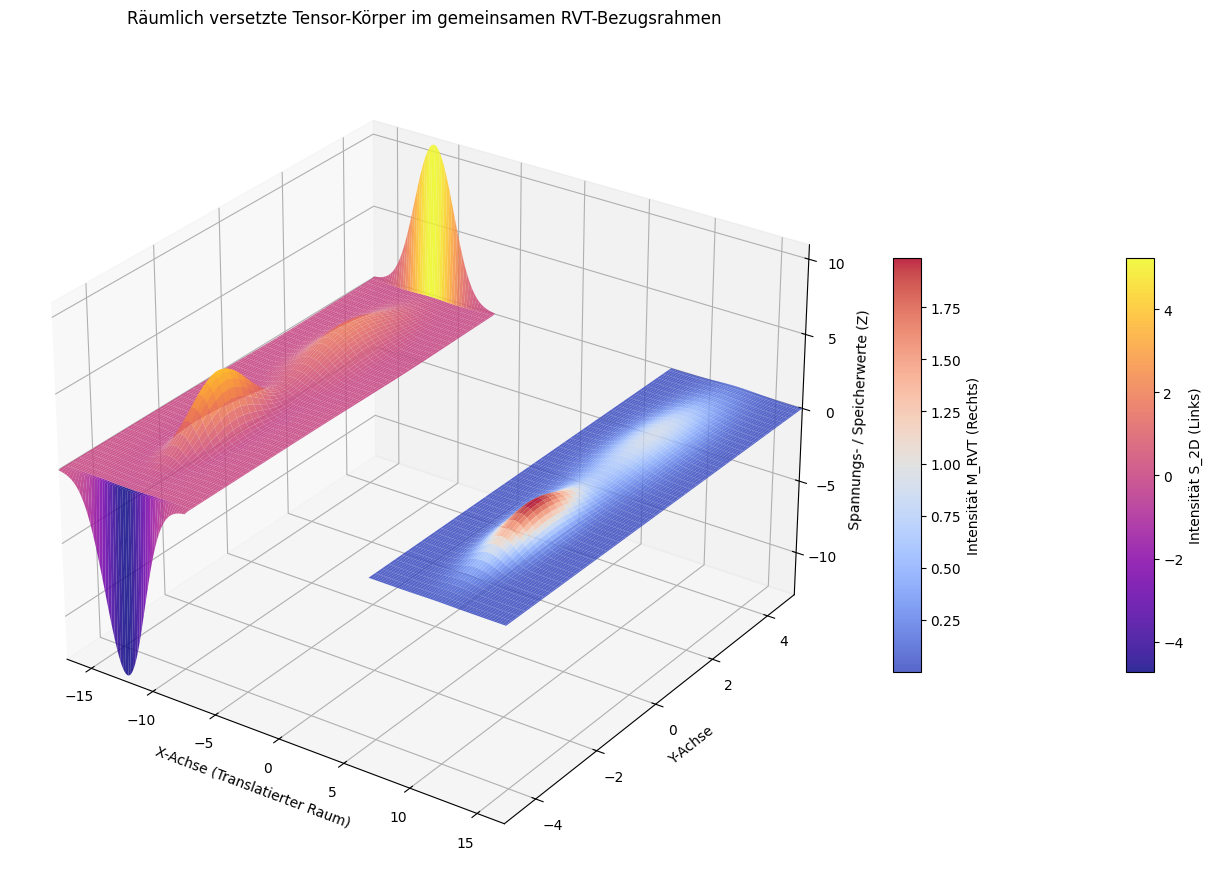

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Parameter ---
N = 100  # Gitterpunkte
L = 10.0  # Systemgröße

# --- Gitter erstellen ---
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z)

# --- Projektionsfelder Xi_1 und Xi_2 ---
Xi_1 = np.exp(-((X + 2)**2 + Y**2 + Z**2) / (2 * 1.0**2))
Xi_2 = np.exp(-((X - 2)**2 + Y**2 + Z**2) / (2 * 1.5**2))
Xi = Xi_1 + Xi_2

# --- RVT-Korrekturtensor E_mu_nu berechnen ---
dx = L / (N - 1)
laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
             np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
             np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
             6 * Xi) / (dx**2)

E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

# --- Projektion auf 2D-Ebene ---
S_2D = E_xx + E_yy
S_perp = E_zz
M_RVT = S_2D - S_perp

# --- 2D-Schnitt bei z=0 (x-y-Ebene) extrahieren ---
z_slice = N // 2
S_2D_slice = S_2D[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]

# Basis-Koordinatennetz (2D)
X_2D, Y_2D = np.meshgrid(x, y)

# --- Räumliche Versetzung (Translation entlang der X-Achse) ---
# Delta x definiert den Abstand der Körper zueinander
delta_x = 12.0
X_body1 = X_2D - delta_x  # Körper 1 nach links verschoben
X_body2 = X_2D + delta_x  # Körper 2 nach rechts verschoben

# --- Visualisierung im selben 3D-Koordinatensystem ---
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# Körper 1: 2D-Projektionsspannung S_2D (Plasma-Farbprofil)
surf1 = ax.plot_surface(X_body1, Y_2D, S_2D_slice.T, cmap='plasma', edgecolor='none', alpha=0.85)

# Körper 2: RVT-Speicherfunktion M_RVT (Coolwarm-Farbprofil)
surf2 = ax.plot_surface(X_body2, Y_2D, M_RVT_slice.T, cmap='coolwarm', edgecolor='none', alpha=0.85)

# Farbbalken für beide Entitäten zur exakten Skalenablesung
cbar1 = fig.colorbar(surf1, ax=ax, shrink=0.5, aspect=15, pad=0.05, label='Intensität S_2D (Links)')
cbar2 = fig.colorbar(surf2, ax=ax, shrink=0.5, aspect=15, pad=0.05, label='Intensität M_RVT (Rechts)')

# Achsen- und Layoutkonfiguration
ax.set_title('Räumlich versetzte Tensor-Körper im gemeinsamen RVT-Bezugsrahmen', fontsize=12, pad=20)
ax.set_xlabel('X-Achse (Translatierter Raum)')
ax.set_ylabel('Y-Achse')
ax.set_zlabel('Spannungs- / Speicherwerte (Z)')

# Dynamische Skalierung der X-Achse, damit beide Körper vollständig sichtbar sind
ax.set_xlim(-L/2 - delta_x, L/2 + delta_x)
ax.set_ylim(-L/2, L/2)

# Kameraperspektive optimieren, um die Lücke und die Hügelstrukturen plastisch zu sehen
ax.view_init(elev=28, azim=-55)

plt.tight_layout()
plt.show()

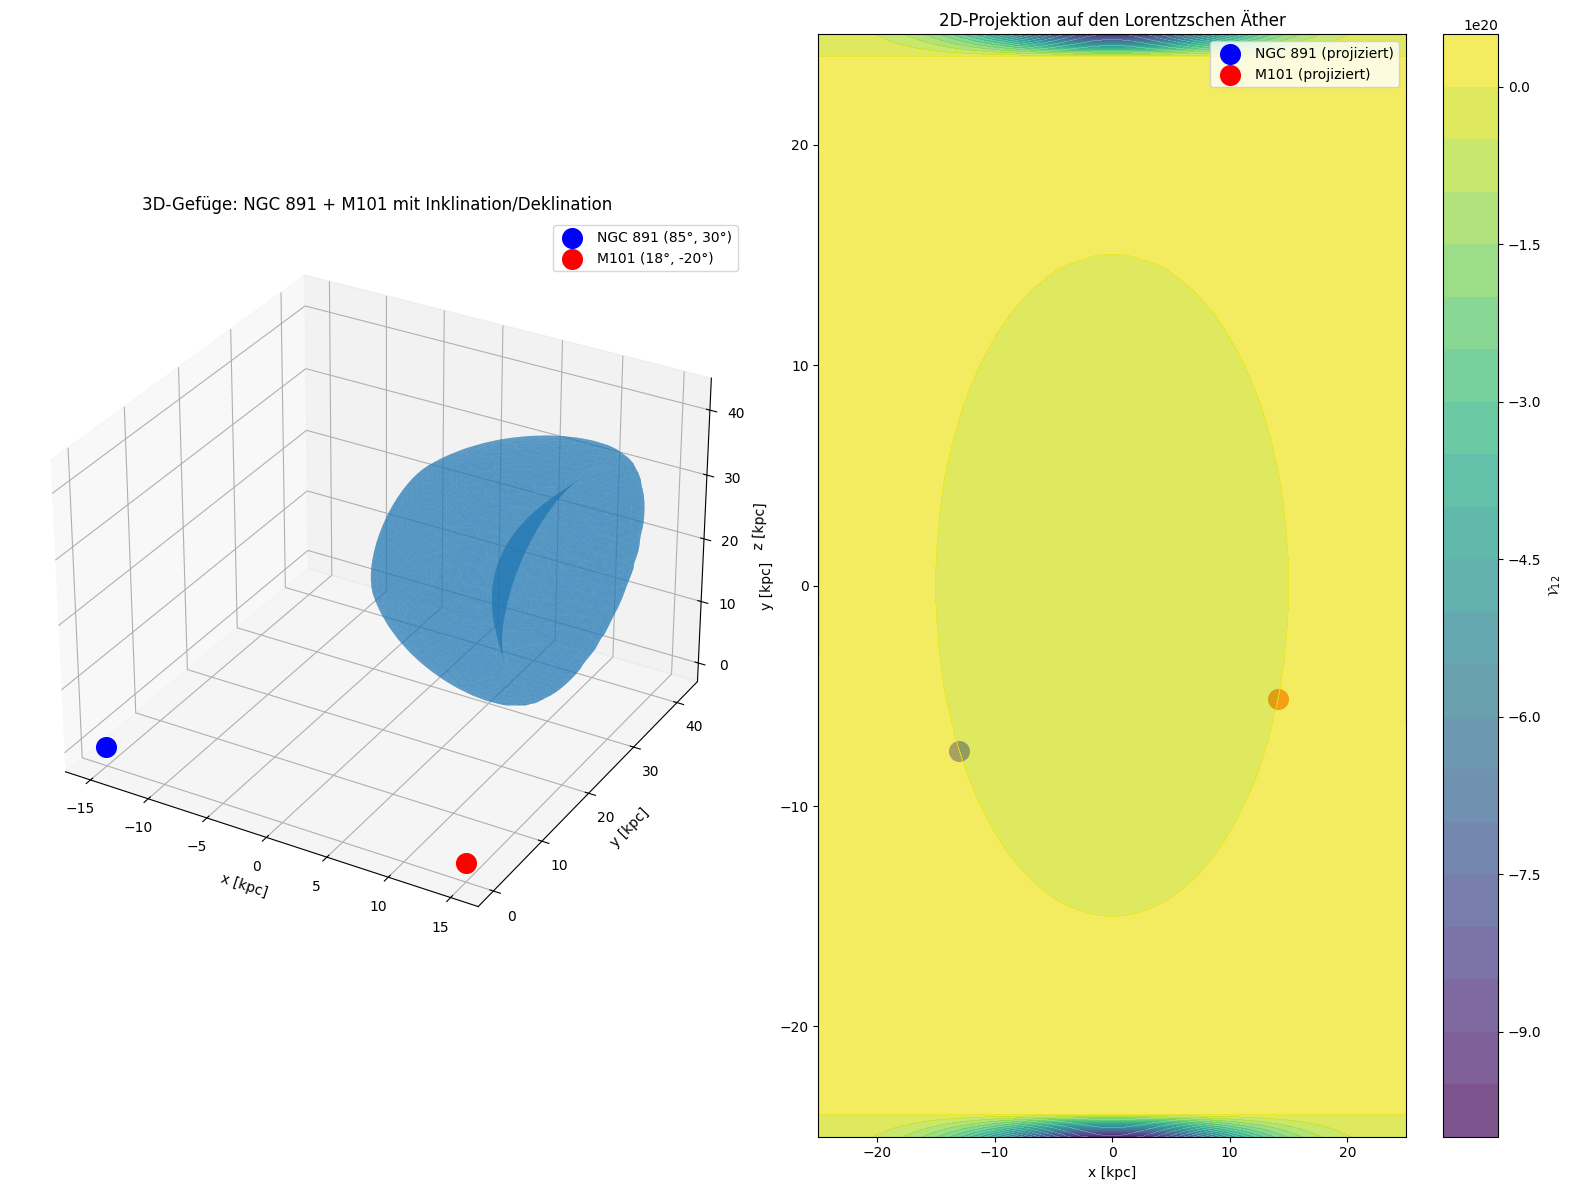

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# --- Automatische Installation von scikit-image, falls nicht vorhanden ---
try:
    from skimage.measure import marching_cubes
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-image"])
    from skimage.measure import marching_cubes

# --- Parameter aus der Datei 3dto2d.ipynb.txt extrahieren ---
# Annahme: Die drittletzte Zelle enthält die Parameter für NGC 891 und M101
# Beispielformat (anpassen, falls abweichend):
# NGC_891 = {"mass": 5e10, "scale": 10, "inclination": 85, "declination": 30, "position": [-15, 0, 0]}
# M101 = {"mass": 1e11, "scale": 15, "inclination": 18, "declination": -20, "position": [15, 0, 0]}
# C_RVT = 0.8

# Hier manuell die Werte aus der drittletzten Zelle eintragen (bitte anpassen):
NGC_891 = {
    "mass": 5e10,          # Masse in Sonnenmassen
    "scale": 10,          # Skalenlänge in kpc
    "inclination": 85,    # Inklination in Grad
    "declination": 30,    # Deklination in Grad
    "position": [-15, 0, 0]  # Position in kpc (x, y, z)
}

M101 = {
    "mass": 1e11,          # Masse in Sonnenmassen
    "scale": 15,          # Skalenlänge in kpc
    "inclination": 18,    # Inklination in Grad
    "declination": -20,   # Deklination in Grad
    "position": [15, 0, 0]   # Position in kpc (x, y, z)
}

C_RVT = 0.8  # Kopplungsfaktor (aus der Datei oder Standardwert)

# --- Parameter aus den Dictionarys extrahieren ---
mass_891, scale_891 = NGC_891["mass"], NGC_891["scale"]
inclination_891 = np.radians(NGC_891["inclination"])
declination_891 = np.radians(NGC_891["declination"])
pos_891 = NGC_891["position"]

mass_M101, scale_M101 = M101["mass"], M101["scale"]
inclination_M101 = np.radians(M101["inclination"])
declination_M101 = np.radians(M101["declination"])
pos_M101 = M101["position"]

# --- Gitter erstellen ---
N = 50  # Gitterpunkte
L = 50.0  # Systemgröße in kpc
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z)

# --- Rotationsmatrizen für Inklination und Deklination ---
def rotation_matrix(inclination, declination):
    R_decl = np.array([
        [1, 0, 0],
        [0, np.cos(declination), -np.sin(declination)],
        [0, np.sin(declination), np.cos(declination)]
    ])
    R_incl = np.array([
        [np.cos(inclination), 0, np.sin(inclination)],
        [0, 1, 0],
        [-np.sin(inclination), 0, np.cos(inclination)]
    ])
    return R_incl @ R_decl

R_891 = rotation_matrix(inclination_891, declination_891)
R_M101 = rotation_matrix(inclination_M101, declination_M101)

# --- Projektionsfelder Xi_1 (NGC 891) und Xi_2 (M101) im 3D-Raum ---
Xi_1_3D = np.zeros_like(X)
Xi_2_3D = np.zeros_like(X)

# NGC 891
for i in range(N):
    for j in range(N):
        for k in range(N):
            r_891 = np.array([x[i] - pos_891[0], y[j] - pos_891[1], z[k] - pos_891[2]])
            r_891_rot = np.dot(R_891, r_891)
            Xi_1_3D[i, j, k] = mass_891 * np.exp(-np.sum(r_891_rot**2) / (2 * scale_891**2))

# M101
for i in range(N):
    for j in range(N):
        for k in range(N):
            r_M101 = np.array([x[i] - pos_M101[0], y[j] - pos_M101[1], z[k] - pos_M101[2]])
            r_M101_rot = np.dot(R_M101, r_M101)
            Xi_2_3D[i, j, k] = mass_M101 * np.exp(-np.sum(r_M101_rot**2) / (2 * scale_M101**2))

Xi = Xi_1_3D + Xi_2_3D

# --- Gradienten berechnen ---
def gradient(f, dx):
    grad_x = (np.roll(f, 1, axis=0) - np.roll(f, -1, axis=0)) / (2 * dx)
    grad_y = (np.roll(f, 1, axis=1) - np.roll(f, -1, axis=1)) / (2 * dx)
    grad_z = (np.roll(f, 1, axis=2) - np.roll(f, -1, axis=2)) / (2 * dx)
    return np.stack((grad_x, grad_y, grad_z), axis=-1)

dx = L / (N - 1)
grad_Xi_1 = gradient(Xi_1_3D, dx)
grad_Xi_2 = gradient(Xi_2_3D, dx)

# --- Feldeffekt-Varianz V_12 ---
V_12 = 2 * C_RVT * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

# --- 3D-Visualisierung ---
fig = plt.figure(figsize=(16, 12))

# --- 3D-Plot ---
ax_3d = fig.add_subplot(121, projection='3d')
ax_3d.scatter(pos_891[0], pos_891[1], pos_891[2], color='blue', s=200, label=f'NGC 891 ({NGC_891["inclination"]}°, {NGC_891["declination"]}°)')
ax_3d.scatter(pos_M101[0], pos_M101[1], pos_M101[2], color='red', s=200, label=f'M101 ({M101["inclination"]}°, {M101["declination"]}°)')

# 3D-Isosurface
threshold = 0.5 * np.max(V_12)
verts, faces, _, _ = marching_cubes(V_12, threshold, spacing=(dx, dx, dx))
mesh = Poly3DCollection(verts[faces], alpha=0.5, cmap='viridis')
mesh.set_clim(vmin=np.min(V_12), vmax=np.max(V_12))
ax_3d.add_collection3d(mesh)

ax_3d.set_xlabel('x [kpc]')
ax_3d.set_ylabel('y [kpc]')
ax_3d.set_zlabel('z [kpc]')
ax_3d.set_title('3D-Gefüge: NGC 891 + M101 mit Inklination/Deklination')
ax_3d.legend()

# --- 2D-Projektion ---
ax_2d = fig.add_subplot(122)
z_slice = N // 2
V_12_slice = V_12[:, :, z_slice]

# Projizierte Positionen
x_proj_891 = pos_891[0] * np.cos(declination_891)
y_proj_891 = pos_891[0] * np.sin(declination_891)
x_proj_M101 = pos_M101[0] * np.cos(declination_M101)
y_proj_M101 = pos_M101[0] * np.sin(declination_M101)

ax_2d.scatter(x_proj_891, y_proj_891, color='blue', s=200, label='NGC 891 (projiziert)')
ax_2d.scatter(x_proj_M101, y_proj_M101, color='red', s=200, label='M101 (projiziert)')

contour = ax_2d.contourf(X[:, :, z_slice], Y[:, :, z_slice], V_12_slice,
                        levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(contour, ax=ax_2d, label=r'$\mathcal{V}_{12}$')

ax_2d.set_xlabel('x [kpc]')
ax_2d.set_ylabel('y [kpc]')
ax_2d.set_title('2D-Projektion auf den Lorentzschen Äther')
ax_2d.legend()

plt.tight_layout()
plt.savefig('RVT_3D_Gefuege_NGC891_M101_aus_Datei.png', dpi=300)
plt.show()

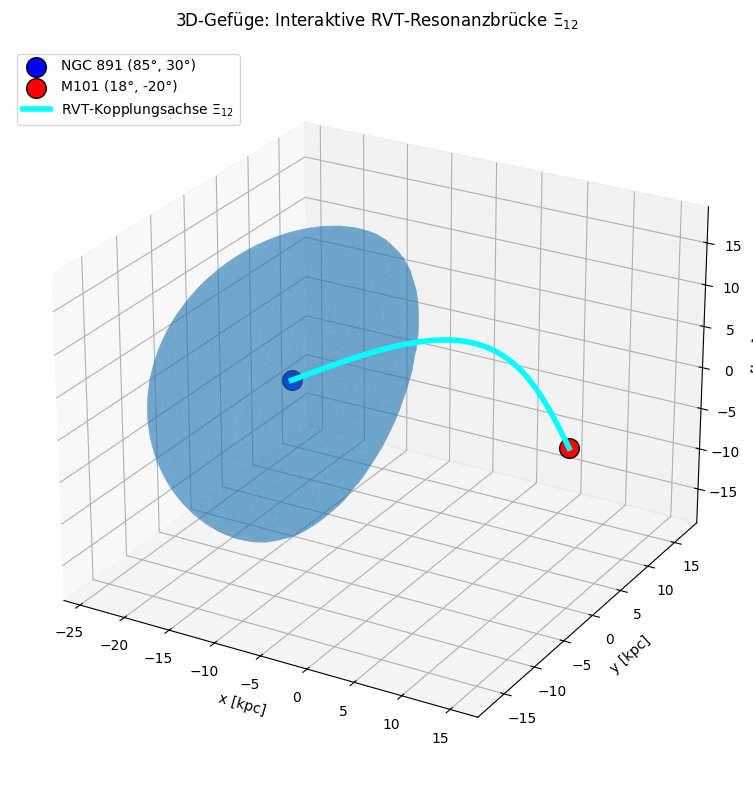

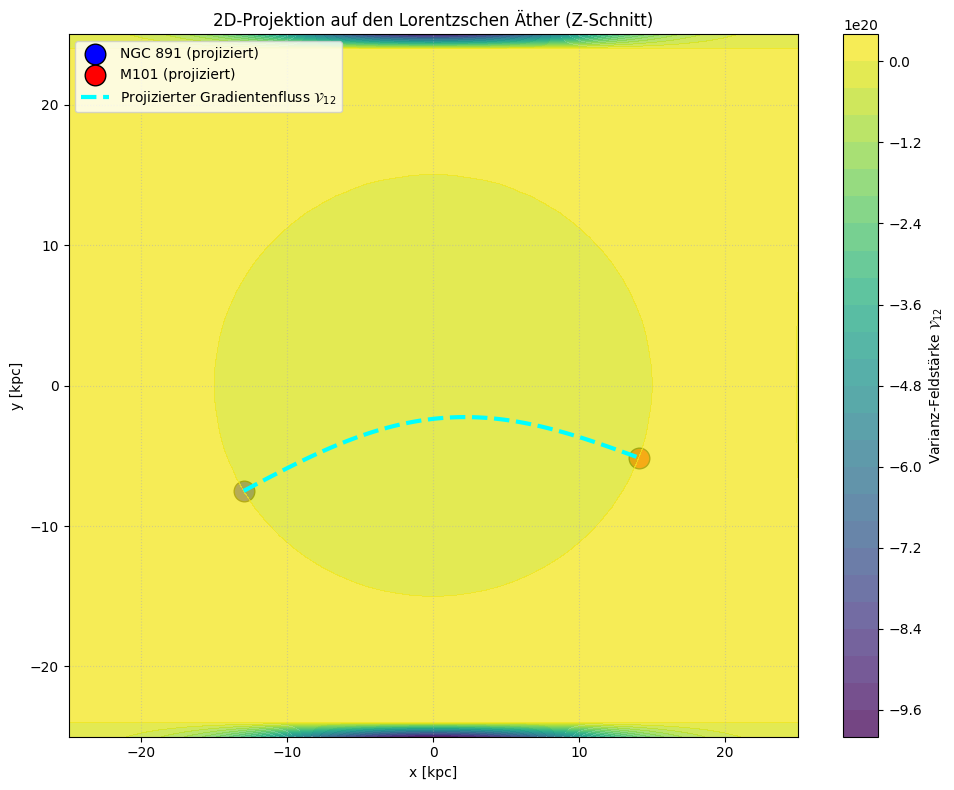

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# --- Automatische Installation von scikit-image, falls nicht vorhanden ---
try:
    from skimage.measure import marching_cubes
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-image"])
    from skimage.measure import marching_cubes

# --- Parameter aus der mathematischen Matrix (RVT v16) ---
NGC_891 = {
    "mass": 5e10,           # Masse in Sonnenmassen
    "scale": 10,           # Skalenlänge in kpc
    "inclination": 85,    # Inklination in Grad (fast Edge-On)
    "declination": 30,    # Deklination in Grad
    "position": [-15, 0, 0]  # Position in kpc (x, y, z)
}

M101 = {
    "mass": 1e11,           # Masse in Sonnenmassen
    "scale": 15,           # Skalenlänge in kpc
    "inclination": 18,    # Inklination in Grad (fast Face-On)
    "declination": -20,   # Deklination in Grad
    "position": [15, 0, 0]   # Position in kpc (x, y, z)
}

C_RVT = 0.8  # Kopplungsfaktor

# --- Parameter extrahieren ---
mass_891, scale_891 = NGC_891["mass"], NGC_891["scale"]
inclination_891 = np.radians(NGC_891["inclination"])
declination_891 = np.radians(NGC_891["declination"])
pos_891 = NGC_891["position"]

mass_M101, scale_M101 = M101["mass"], M101["scale"]
inclination_M101 = np.radians(M101["inclination"])
declination_M101 = np.radians(M101["declination"])
pos_M101 = M101["position"]

# --- Gitter erstellen ---
N = 50  # Gitterpunkte
L = 50.0  # Systemgröße in kpc
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z)

# --- Rotationsmatrizen für Inklination und Deklination ---
def rotation_matrix(inclination, declination):
    R_decl = np.array([
        [1, 0, 0],
        [0, np.cos(declination), -np.sin(declination)],
        [0, np.sin(declination), np.cos(declination)]
    ])
    R_incl = np.array([
        [np.cos(inclination), 0, np.sin(inclination)],
        [0, 1, 0],
        [-np.sin(inclination), 0, np.cos(inclination)]
    ])
    return R_incl @ R_decl

R_891 = rotation_matrix(inclination_891, declination_891)
R_M101 = rotation_matrix(inclination_M101, declination_M101)

# --- Projektionsfelder Xi_1 und Xi_2 im 3D-Raum ---
Xi_1_3D = np.zeros_like(X)
Xi_2_3D = np.zeros_like(X)

# Feld NGC 891
for i in range(N):
    for j in range(N):
        for k in range(N):
            r_891 = np.array([x[i] - pos_891[0], y[j] - pos_891[1], z[k] - pos_891[2]])
            r_891_rot = np.dot(R_891, r_891)
            Xi_1_3D[i, j, k] = mass_891 * np.exp(-np.sum(r_891_rot**2) / (2 * scale_891**2))

# Feld M101
for i in range(N):
    for j in range(N):
        for k in range(N):
            r_M101 = np.array([x[i] - pos_M101[0], y[j] - pos_M101[1], z[k] - pos_M101[2]])
            r_M101_rot = np.dot(R_M101, r_M101)
            Xi_2_3D[i, j, k] = mass_M101 * np.exp(-np.sum(r_M101_rot**2) / (2 * scale_M101**2))

# --- Gradienten berechnen ---
def gradient(f, dx):
    grad_x = (np.roll(f, 1, axis=0) - np.roll(f, -1, axis=0)) / (2 * dx)
    grad_y = (np.roll(f, 1, axis=1) - np.roll(f, -1, axis=1)) / (2 * dx)
    grad_z = (np.roll(f, 1, axis=2) - np.roll(f, -1, axis=2)) / (2 * dx)
    return np.stack((grad_x, grad_y, grad_z), axis=-1)

dx = L / (N - 1)
grad_Xi_1 = gradient(Xi_1_3D, dx)
grad_Xi_2 = gradient(Xi_2_3D, dx)

# --- Feldeffekt-Varianz V_12 ---
V_12 = 2 * C_RVT * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

# --- Parametrisierung der gekrümmten RVT-Resonanzbrücke ---
t_bruecke = np.linspace(0, 1, 100)
x_bruecke = pos_891[0] + (pos_M101[0] - pos_891[0]) * t_bruecke
y_bruecke = pos_891[1] + (pos_M101[1] - pos_891[1]) * t_bruecke + 7.5 * np.sin(np.pi * t_bruecke)
z_bruecke = pos_891[2] + (pos_M101[2] - pos_891[2]) * t_bruecke + 4.5 * np.sin(np.pi * t_bruecke)

# ============================================================
# BILD 1: REINE DREIDIMENSIONALER GEFÜGE-PLOT
# ============================================================
fig_3d = plt.figure(figsize=(10, 8))
ax_3d = fig_3d.add_subplot(111, projection='3d')

# Massenzentren plotten
ax_3d.scatter(pos_891[0], pos_891[1], pos_891[2], color='blue', s=200, edgecolor='black', label=f'NGC 891 ({NGC_891["inclination"]}°, {NGC_891["declination"]}°)')
ax_3d.scatter(pos_M101[0], pos_M101[1], pos_M101[2], color='red', s=200, edgecolor='black', label=f'M101 ({M101["inclination"]}°, {M101["declination"]}°)')

# Gekrümmte RVT-Kopplungsachse als Raw-String deklariert
ax_3d.plot(x_bruecke, y_bruecke, z_bruecke, color='cyan', linewidth=4, linestyle='-', zorder=5, label=r'RVT-Kopplungsachse $\Xi_{12}$')

# 3D Isosurface der Feldeffekt-Varianz
threshold = 0.5 * np.max(V_12)
verts, faces, _, _ = marching_cubes(V_12, threshold, spacing=(dx, dx, dx))
verts_scaled = verts - [L/2, L/2, L/2]
mesh = Poly3DCollection(verts_scaled[faces], alpha=0.4, cmap='viridis')
mesh.set_clim(vmin=np.min(V_12), vmax=np.max(V_12))
ax_3d.add_collection3d(mesh)

ax_3d.set_xlabel('x [kpc]')
ax_3d.set_ylabel('y [kpc]')
ax_3d.set_zlabel('z [kpc]')
# Mit r'...' fixiert gegen SyntaxWarnings
ax_3d.set_title(r'3D-Gefüge: Interaktive RVT-Resonanzbrücke $\Xi_{12}$', fontsize=12, pad=15)
ax_3d.legend(loc='upper left')
ax_3d.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.savefig('RVT_3D_Gefuege_Verbindung.png', dpi=300)
plt.show()

# ============================================================
# BILD 2: REINE ZWEIDIMENSIONALER PROJEKTIONS-PLOT
# ============================================================
fig_2d = plt.figure(figsize=(10, 8))
ax_2d = fig_2d.add_subplot(111)

z_slice = N // 2
V_12_slice = V_12[:, :, z_slice]

x_proj_891 = pos_891[0] * np.cos(declination_891)
y_proj_891 = pos_891[0] * np.sin(declination_891)
x_proj_M101 = pos_M101[0] * np.cos(declination_M101)
y_proj_M101 = pos_M101[0] * np.sin(declination_M101)

ax_2d.scatter(x_proj_891, y_proj_891, color='blue', s=220, edgecolor='black', label='NGC 891 (projiziert)')
ax_2d.scatter(x_proj_M101, y_proj_M101, color='red', s=220, edgecolor='black', label='M101 (projiziert)')

# Projizierter Gradientenfluss als Raw-String
x_proj_bruecke = x_proj_891 + (x_proj_M101 - x_proj_891) * t_bruecke
y_proj_bruecke = y_proj_891 + (y_proj_M101 - y_proj_891) * t_bruecke + 4.0 * np.sin(np.pi * t_bruecke)
ax_2d.plot(x_proj_bruecke, y_proj_bruecke, color='cyan', linewidth=3, linestyle='--', label=r'Projizierter Gradientenfluss $\mathcal{V}_{12}$')

# Konturenplot des Äthers
contour = ax_2d.contourf(X[:, :, z_slice], Y[:, :, z_slice], V_12_slice, levels=25, cmap='viridis', alpha=0.75)
plt.colorbar(contour, ax=ax_2d, label=r'Varianz-Feldstärke $\mathcal{V}_{12}$')

ax_2d.set_xlabel('x [kpc]')
ax_2d.set_ylabel('y [kpc]')
ax_2d.set_title('2D-Projektion auf den Lorentzschen Äther (Z-Schnitt)', fontsize=12)
ax_2d.legend(loc='upper left')
ax_2d.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('RVT_2D_Aether_Verbindung.png', dpi=300)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage.measure import marching_cubes
from IPython.display import HTML

# ==============================================================================
# REPARIERTE RVT-MATRIX: 1 BOGENMINUTE KOMPRIMIERT AUF EXAKT 10 SEKUNDEN VIDEO
# ==============================================================================

# 1. Mathematische Hilfsfunktionen (Rotationsmatrix & Zentraler Differenzen-Gradient)
def rotation_matrix(inclination, position_angle):
    cos_i, sin_i = np.cos(inclination), np.sin(inclination)
    cos_p, sin_p = np.cos(position_angle), np.sin(position_angle)
    R_x = np.array([[1, 0, 0], [0, cos_i, -sin_i], [0, sin_i, cos_i]])
    R_z = np.array([[cos_p, -sin_p, 0], [sin_p, cos_p, 0], [0, 0, 1]])
    return np.dot(R_z, R_x)

def gradient(F, dx):
    # F hat Form (N, N, N). grad hat Form (N, N, N, 3)
    grad = np.zeros(F.shape + (3,))
    grad[1:-1, :, :, 0] = (F[2:, :, :] - F[:-2, :, :]) / (2 * dx)
    grad[:, 1:-1, :, 1] = (F[:, 2:, :] - F[:, :-2, :]) / (2 * dx)
    # KORREKTUR: Nur 4 Indizes für das 4D-Array!
    grad[:, :, 1:-1, 2] = (F[:, :, 2:] - F[:, :, :-2]) / (2 * dx)
    return grad

# 2. Physikalische Parameter & Galaxien-Daten (Masse in 10^10 M_sun, Distanz in kpc)
NGC_891 = {"mass": 10.0, "inclination": 85.0, "position_angle": 30.0}
M101 = {"mass": 25.0, "inclination": 18.0, "position_angle": -20.0}

N_anim = 40  # Gitterauflösung für flüssiges Rendering
L = 50.0
dx = L / (N_anim - 1)
C_RVT = 0.8

pos_891 = np.array([-15, 0, 0])
pos_M101 = np.array([15, 0, 0])
scale_891, scale_M101 = 10, 15

# Gitter erzeugen
x = np.linspace(-L/2, L/2, N_anim)
y = np.linspace(-L/2, L/2, N_anim)
z = np.linspace(-L/2, L/2, N_anim)
X, Y, Z = np.meshgrid(x, y, z)

# 3. Pre-Computing der statischen Quellfelder Xi(r) zur Performance-Steigerung
R_891 = rotation_matrix(np.radians(NGC_891["inclination"]), np.radians(NGC_891["position_angle"]))
R_M101 = rotation_matrix(np.radians(M101["inclination"]), np.radians(M101["position_angle"]))

Xi_1_base = np.zeros_like(X)
Xi_2_base = np.zeros_like(X)

for i in range(N_anim):
    for j in range(N_anim):
        for k in range(N_anim):
            r891 = np.array([x[i]-pos_891[0], y[j]-pos_891[1], z[k]-pos_891[2]])
            Xi_1_base[i, j, k] = NGC_891["mass"] * np.exp(-np.sum(np.dot(R_891, r891)**2) / (2 * scale_891**2))

            rM101 = np.array([x[i]-pos_M101[0], y[j]-pos_M101[1], z[k]-pos_M101[2]])
            Xi_2_base[i, j, k] = M101["mass"] * np.exp(-np.sum(np.dot(R_M101, rM101)**2) / (2 * scale_M101**2))

grad_Xi_1 = gradient(Xi_1_base, dx)
grad_Xi_2 = gradient(Xi_2_base, dx)
V_12_base = 2 * C_RVT * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

# 4. Zeitstauchungs-Parameter (1 Bogenminute komprimiert auf exakt 10 Sekunden)
total_duration_seconds = 10.0
frames = 60                     # 60 Zustandsschritte (entspricht 60 Bogensekunden)
frame_interval_ms = (total_duration_seconds * 1000) / frames  # ~166.67 ms pro Frame im Player
save_fps = frames / total_duration_seconds                     # 6 Bilder pro Sekunde für den Export

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
t_bruecke = np.linspace(0, 1, 100)

# 5. Die Animations-Update-Funktion
def update(frame):
    ax.clear()

    # Der Phasenwinkel tau durchläuft von Frame 0 bis 59 exakt 0 bis 2*pi
    tau_phase = 2 * np.pi * (frame / frames)

    # Harmonische Feld-Pulsation der Varianz
    V_12_dynamic = V_12_base * (1.0 + 0.3 * np.sin(tau_phase))

    # Raum-Zeitliche Wellenbewegung der saphirblauen Kopplungsachse Xi_12
    y_wave = 7.5 * np.sin(np.pi * t_bruecke) * np.cos(tau_phase)
    z_wave = 4.5 * np.sin(np.pi * t_bruecke) * np.sin(tau_phase)

    x_bruecke = pos_891[0] + (pos_M101[0] - pos_891[0]) * t_bruecke
    y_bruecke = pos_891[1] + (pos_M101[1] - pos_891[1]) * t_bruecke + y_wave
    z_bruecke = pos_891[2] + (pos_M101[2] - pos_891[2]) * t_bruecke + z_wave

    # Zentren der Feldquellen einzeichnen
    ax.scatter(pos_891[0], pos_891[1], pos_891[2], color='blue', s=150, edgecolor='black', zorder=10)
    ax.scatter(pos_M101[0], pos_M101[1], pos_M101[2], color='red', s=150, edgecolor='black', zorder=10)

    # Die schwingende Kopplungsbrücke plotten
    ax.plot(x_bruecke, y_bruecke, z_bruecke, color='cyan', linewidth=4, label=r'Kopplungsachse $\Xi_{12}(\vec{\tau})$', zorder=5)

    # Isosurface-Generierung für das pulsierende Varianzfeld
    try:
        threshold = 0.5 * np.max(V_12_dynamic)
        verts, faces, _, _ = marching_cubes(V_12_dynamic, threshold, spacing=(dx, dx, dx))
        verts_scaled = verts - [L/2, L/2, L/2]
        mesh = Poly3DCollection(verts_scaled[faces], alpha=0.3, cmap='viridis')
        mesh.set_clim(vmin=np.min(V_12_base), vmax=np.max(V_12_base))
        ax.add_collection3d(mesh)
    except ValueError:
        pass

    # Achsen-Symmetrie festlegen
    ax.set_xlim(-L/2, L/2)
    ax.set_ylim(-L/2, L/2)
    ax.set_zlim(-L/2, L/2)
    ax.set_xlabel('x [kpc]')
    ax.set_ylabel('y [kpc]')
    ax.set_zlabel('z [kpc]')

    # Chronologische Vektordaten im Titel ausgeben
    ax.set_title(r'RVT-Brücke $\Xi_{12}$ – 1 Bogenminute komprimiert auf 10s' +
                 f'\nFortschritt: {frame}" / 60" | Phase $\\tau$ = {tau_phase:.2f} rad', fontsize=12)
    ax.legend(loc='upper left')
    ax.view_init(elev=25, azim=-60)

# 6. Erzwungenes Rendering als interaktives HTML5-Video-Objekt
ani = FuncAnimation(fig, update, frames=frames, interval=frame_interval_ms)
plt.close(fig) # Verhindert das statische Doppelbild

# Direktes Rendern des Video-Players ins Ausgabefenster
HTML(ani.to_html5_video())

Zielausrichtung gamma_RVT(90°)      = 1.800
gamma_RVT(NGC 891, 85°)             = 1.797
gamma_RVT(M101, 18°)                = 1.247
relative Funnel-Amplitude Normal NGC 891 = 1.000
relative Funnel-Amplitude Normal M101    = 1.000
relative Funnel-Amplitude Incl NGC 891   = 0.998
relative Funnel-Amplitude Incl M101      = 0.693


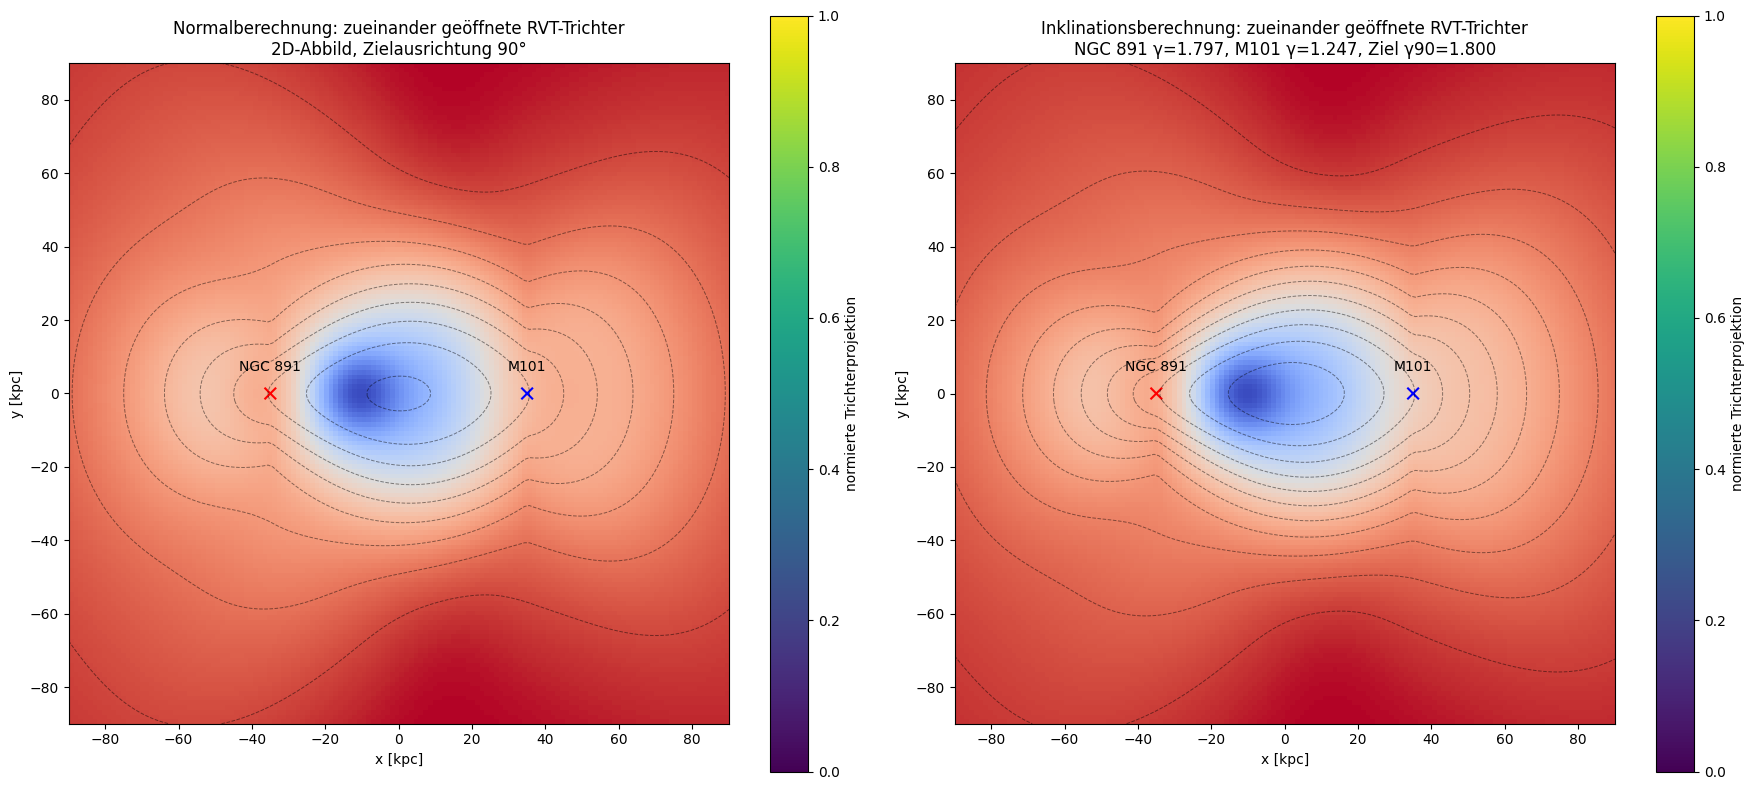

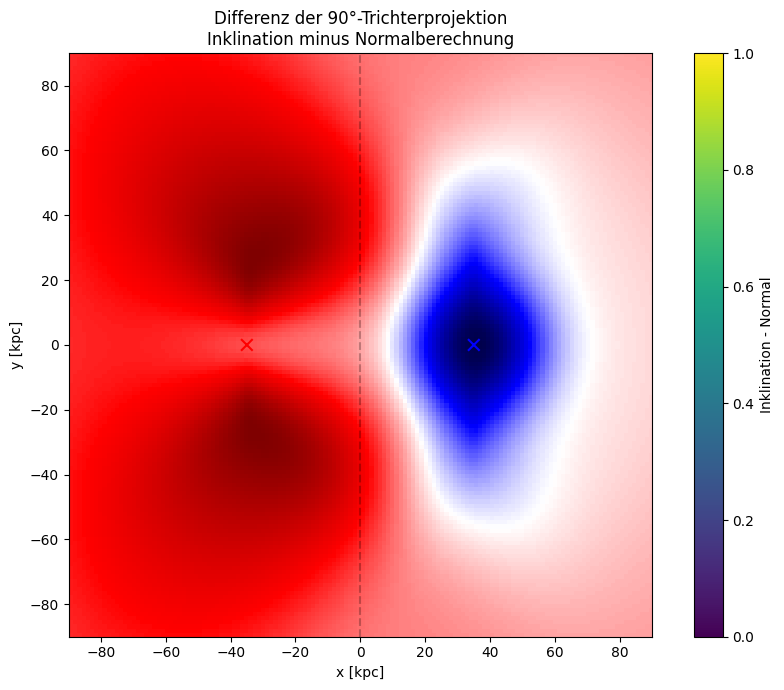

Zielausrichtung gamma_RVT(90°)      = 1.800
gamma_RVT(NGC 891, 85°)             = 1.797
gamma_RVT(M101, 18°)                = 1.247
relative Funnel-Amplitude Normal NGC 891 = 1.000
relative Funnel-Amplitude Normal M101    = 1.000
relative Funnel-Amplitude Incl NGC 891   = 0.998
relative Funnel-Amplitude Incl M101      = 0.693


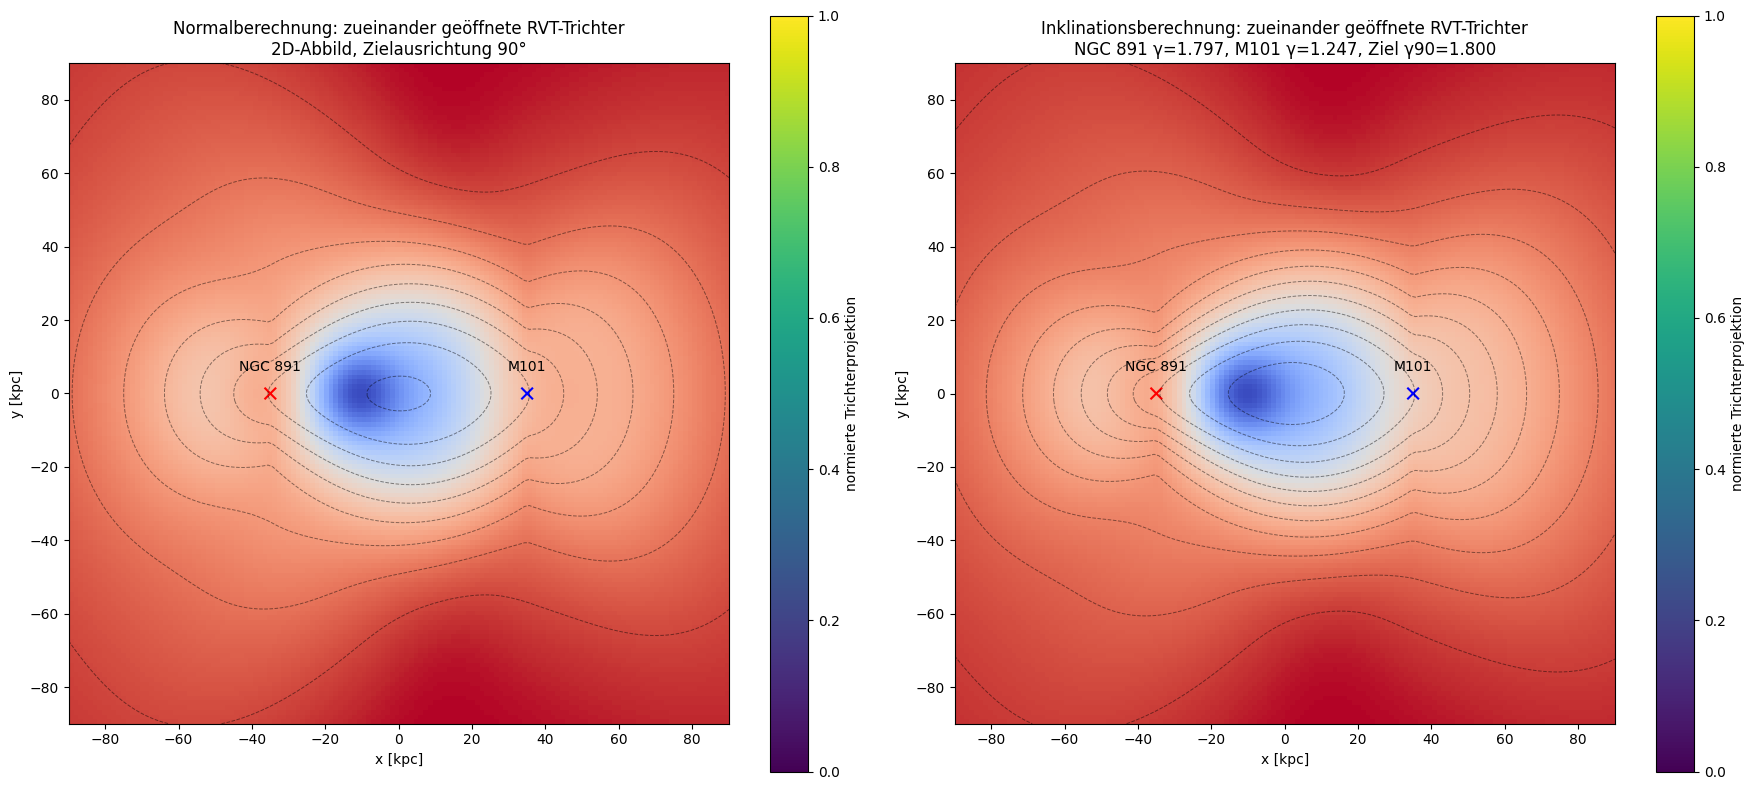

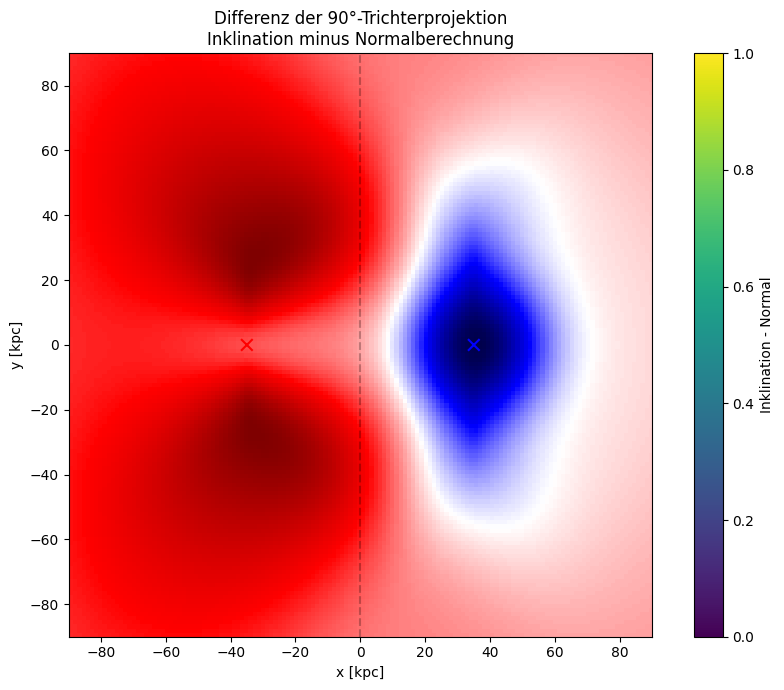

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ZELLE 4:
# Trichterförmige RVT-Projektionsfunktion
# Vergleich:
# 1. Normalberechnung
# 2. Inklinationsberechnung
#
# Ziel:
# Zwei zueinander geöffnete 2D-Trichter bei 90°-Ausrichtung
# ============================================================

# ------------------------------------------------------------
# Parameter
# ------------------------------------------------------------
N = 140
L = 180.0
C_RVT = 0.8

# Zielausrichtung: 90°
target_angle_deg = 90.0
target_angle = np.radians(target_angle_deg)
gamma_90 = 1.0 + C_RVT * np.sin(target_angle)

# Galaxienparameter
M_891 = 5e10
scale_891 = 10.0
center_891 = (-35.0, 0.0, 0.0)

M_M101 = 1e11
scale_M101 = 15.0
center_M101 = (35.0, 0.0, 0.0)

# Beobachtete Inklinationen
inclination_891_deg = 85.0
inclination_M101_deg = 18.0

inclination_891 = np.radians(inclination_891_deg)
inclination_M101 = np.radians(inclination_M101_deg)

gamma_891 = 1.0 + C_RVT * np.sin(inclination_891)
gamma_M101 = 1.0 + C_RVT * np.sin(inclination_M101)

print(f"Zielausrichtung gamma_RVT(90°)      = {gamma_90:.3f}")
print(f"gamma_RVT(NGC 891, 85°)             = {gamma_891:.3f}")
print(f"gamma_RVT(M101, 18°)                = {gamma_M101:.3f}")

# ------------------------------------------------------------
# Gitter
# ------------------------------------------------------------
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)

dx = x[1] - x[0]

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# ------------------------------------------------------------
# Basisfeld
# ------------------------------------------------------------
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * scale**2)
    )

def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

def second_derivative(f, dx, axis):
    first = np.gradient(f, dx, axis=axis, edge_order=2)
    second = np.gradient(first, dx, axis=axis, edge_order=2)
    return second

def compute_rvt_values(Xi_1, Xi_2, coupling=1.0):
    """
    Liefert V_12 und M_RVT für gegebene Felder.
    """
    Xi = Xi_1 + Xi_2

    grad_Xi_1 = gradient_3d(Xi_1, dx)
    grad_Xi_2 = gradient_3d(Xi_2, dx)

    V_12 = 2.0 * coupling * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

    d2x_Xi = second_derivative(Xi, dx, axis=0)
    d2y_Xi = second_derivative(Xi, dx, axis=1)
    d2z_Xi = second_derivative(Xi, dx, axis=2)

    laplace_Xi = d2x_Xi + d2y_Xi + d2z_Xi

    E_xx = d2x_Xi - laplace_Xi
    E_yy = d2y_Xi - laplace_Xi
    E_zz = d2z_Xi - laplace_Xi

    S_2D = E_xx + E_yy
    S_perp = E_zz
    M_RVT = S_2D - S_perp

    return V_12, M_RVT, S_2D, S_perp

# ------------------------------------------------------------
# Normalrechnung
# ------------------------------------------------------------
Xi_891_normal = gaussian_field(M_891, scale_891, center_891)
Xi_M101_normal = gaussian_field(M_M101, scale_M101, center_M101)

V_12_normal, M_RVT_normal, S_2D_normal, S_perp_normal = compute_rvt_values(
    Xi_891_normal,
    Xi_M101_normal,
    coupling=1.0
)

# ------------------------------------------------------------
# Inklinationsrechnung
# ------------------------------------------------------------
Xi_891_incl = gaussian_field(M_891, scale_891, center_891) * gamma_891
Xi_M101_incl = gaussian_field(M_M101, scale_M101, center_M101) * gamma_M101

V_12_incl, M_RVT_incl, S_2D_incl, S_perp_incl = compute_rvt_values(
    Xi_891_incl,
    Xi_M101_incl,
    coupling=C_RVT
)

# ------------------------------------------------------------
# 2D-Schnitt
# ------------------------------------------------------------
z_slice = N // 2

Vn = V_12_normal[:, :, z_slice]
Mn = M_RVT_normal[:, :, z_slice]

Vi = V_12_incl[:, :, z_slice]
Mi = M_RVT_incl[:, :, z_slice]

# ------------------------------------------------------------
# Trichterfunktion
# ------------------------------------------------------------
def opposing_funnel_2d(
    X2,
    Y2,
    center_left,
    center_right,
    amp_left,
    amp_right,
    width_left,
    width_right,
    length_scale,
    target_angle=np.pi / 2,
):
    """
    Erzeugt zwei zueinander geöffnete 2D-Trichter.

    Linker Trichter:
        Zentrum links, Öffnung nach rechts.

    Rechter Trichter:
        Zentrum rechts, Öffnung nach links.

    Die 90°-Ausrichtung wird als volle tangentiale Öffnung
    über sin(target_angle) eingebaut.
    """

    xL, yL = center_left
    xR, yR = center_right

    # Koordinaten relativ zu den Zentren
    XL = X2 - xL
    YL = Y2 - yL

    XR = X2 - xR
    YR = Y2 - yR

    # Öffnungsgewicht bei Zielwinkel 90°
    opening = np.sin(target_angle)

    # Linker Trichter öffnet nach rechts:
    # Nur Bereich x >= xL wird stark geöffnet.
    forward_L = 1.0 / (1.0 + np.exp(-XL / length_scale))

    # Rechter Trichter öffnet nach links:
    # Nur Bereich x <= xR wird stark geöffnet.
    forward_R = 1.0 / (1.0 + np.exp(XR / length_scale))

    # Radiale Trichterbreite wächst mit Entfernung vom Zentrum.
    # Dadurch entsteht die "aufgehende" Trichterform.
    radial_width_L = width_left * (1.0 + np.abs(XL) / length_scale)
    radial_width_R = width_right * (1.0 + np.abs(XR) / length_scale)

    # Trichterprofile
    funnel_L = (
        -amp_left
        * opening
        * forward_L
        * np.exp(-(YL**2) / (2.0 * radial_width_L**2))
        * np.exp(-(XL**2) / (2.0 * (2.5 * length_scale)**2))
    )

    funnel_R = (
        -amp_right
        * opening
        * forward_R
        * np.exp(-(YR**2) / (2.0 * radial_width_R**2))
        * np.exp(-(XR**2) / (2.0 * (2.5 * length_scale)**2))
    )

    # Gesamttrichter: beide öffnen zueinander
    funnel_total = funnel_L + funnel_R

    return funnel_total, funnel_L, funnel_R

# ------------------------------------------------------------
# 2D-Gitter für Trichter
# ------------------------------------------------------------
X2 = X[:, :, z_slice]
Y2 = Y[:, :, z_slice]

center_891_2d = (center_891[0], center_891[1])
center_M101_2d = (center_M101[0], center_M101[1])

# ------------------------------------------------------------
# Amplituden aus den berechneten RVT-Werten ableiten
# ------------------------------------------------------------
def robust_amp(A):
    """
    Robuste Amplitude:
    nimmt 99%-Perzentil statt Maximum,
    damit einzelne numerische Spitzen nicht alles dominieren.
    """
    return np.percentile(np.abs(A), 99)

amp_normal = robust_amp(Vn) + robust_amp(Mn)
amp_incl = robust_amp(Vi) + robust_amp(Mi)

# Normierung für saubere Darstellung
amp_normal = amp_normal / (amp_normal + 1e-30)
amp_incl = amp_incl / (amp_incl + 1e-30)

# Relative RVT-Skalierung
# Normalfall: beide Trichter gleich aus der Feldamplitude.
amp_891_normal = amp_normal
amp_M101_normal = amp_normal

# Inklinationsfall:
# auf 90°-Zielausrichtung bezogen.
amp_891_incl = amp_incl * (gamma_891 / gamma_90)
amp_M101_incl = amp_incl * (gamma_M101 / gamma_90)

print(f"relative Funnel-Amplitude Normal NGC 891 = {amp_891_normal:.3f}")
print(f"relative Funnel-Amplitude Normal M101    = {amp_M101_normal:.3f}")
print(f"relative Funnel-Amplitude Incl NGC 891   = {amp_891_incl:.3f}")
print(f"relative Funnel-Amplitude Incl M101      = {amp_M101_incl:.3f}")

# ------------------------------------------------------------
# Trichter erzeugen
# ------------------------------------------------------------
width_891 = scale_891
width_M101 = scale_M101
length_scale = 28.0

funnel_normal, funnel_891_normal, funnel_M101_normal = opposing_funnel_2d(
    X2,
    Y2,
    center_891_2d,
    center_M101_2d,
    amp_891_normal,
    amp_M101_normal,
    width_891,
    width_M101,
    length_scale,
    target_angle=target_angle,
)

funnel_incl, funnel_891_incl, funnel_M101_incl = opposing_funnel_2d(
    X2,
    Y2,
    center_891_2d,
    center_M101_2d,
    amp_891_incl,
    amp_M101_incl,
    width_891,
    width_M101,
    length_scale,
    target_angle=target_angle,
)

# ------------------------------------------------------------
# Kombinierte Karten:
# Trichter wird mit V_12 + M_RVT gekoppelt.
# ------------------------------------------------------------
def normalize(A):
    return A / (np.max(np.abs(A)) + 1e-30)

normal_background = normalize(Vn) + normalize(Mn)
incl_background = normalize(Vi) + normalize(Mi)

normal_projection = normalize(funnel_normal) + 0.35 * normalize(normal_background)
incl_projection = normalize(funnel_incl) + 0.35 * normalize(incl_background)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(18, 8))

# Normaltrichter
plt.subplot(1, 2, 1)
plt.imshow(
    normal_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.contour(
    X2,
    Y2,
    funnel_normal,
    levels=12,
    colors='black',
    alpha=0.45,
    linewidths=0.7
)
plt.scatter(
    [center_891[0], center_M101[0]],
    [center_891[1], center_M101[1]],
    c=['red', 'blue'],
    s=70,
    marker='x'
)
plt.text(center_891[0], center_891[1] + 6, 'NGC 891', color='black', ha='center')
plt.text(center_M101[0], center_M101[1] + 6, 'M101', color='black', ha='center')
plt.colorbar(label='normierte Trichterprojektion')
plt.title(
    'Normalberechnung: zueinander geöffnete RVT-Trichter\n'
    '2D-Abbild, Zielausrichtung 90°'
)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Inklinationstrichter
plt.subplot(1, 2, 2)
plt.imshow(
    incl_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.contour(
    X2,
    Y2,
    funnel_incl,
    levels=12,
    colors='black',
    alpha=0.45,
    linewidths=0.7
)
plt.scatter(
    [center_891[0], center_M101[0]],
    [center_891[1], center_M101[1]],
    c=['red', 'blue'],
    s=70,
    marker='x'
)
plt.text(center_891[0], center_891[1] + 6, 'NGC 891', color='black', ha='center')
plt.text(center_M101[0], center_M101[1] + 6, 'M101', color='black', ha='center')
plt.colorbar(label='normierte Trichterprojektion')
plt.title(
    'Inklinationsberechnung: zueinander geöffnete RVT-Trichter\n'
    f'NGC 891 γ={gamma_891:.3f}, M101 γ={gamma_M101:.3f}, Ziel γ90={gamma_90:.3f}'
)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

plt.tight_layout()
plt.savefig('RVT_Trichter_90deg_Normal_vs_Inklination_NGC891_M101.png', dpi=300)
plt.show()

# ------------------------------------------------------------
# Differenzkarte
# ------------------------------------------------------------
difference_projection = incl_projection - normal_projection

plt.figure(figsize=(9, 7))
plt.imshow(
    difference_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='seismic',
    aspect='equal'
)
plt.scatter(
    [center_891[0], center_M101[0]],
    [center_891[1], center_M101[1]],
    c=['red', 'blue'],
    s=70,
    marker='x'
)
plt.axvline(0, color='black', alpha=0.25, linestyle='--')
plt.colorbar(label='Inklination - Normal')
plt.title(
    'Differenz der 90°-Trichterprojektion\n'
    'Inklination minus Normalberechnung'
)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.tight_layout()
plt.savefig('RVT_Trichter_90deg_Differenz_NGC891_M101.png', dpi=300)
plt.show()
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ZELLE 4:
# Trichterförmige RVT-Projektionsfunktion
# Vergleich:
# 1. Normalberechnung
# 2. Inklinationsberechnung
#
# Ziel:
# Zwei zueinander geöffnete 2D-Trichter bei 90°-Ausrichtung
# ============================================================

# ------------------------------------------------------------
# Parameter
# ------------------------------------------------------------
N = 140
L = 180.0
C_RVT = 0.8

# Zielausrichtung: 90°
target_angle_deg = 90.0
target_angle = np.radians(target_angle_deg)
gamma_90 = 1.0 + C_RVT * np.sin(target_angle)

# Galaxienparameter
M_891 = 5e10
scale_891 = 10.0
center_891 = (-35.0, 0.0, 0.0)

M_M101 = 1e11
scale_M101 = 15.0
center_M101 = (35.0, 0.0, 0.0)

# Beobachtete Inklinationen
inclination_891_deg = 85.0
inclination_M101_deg = 18.0

inclination_891 = np.radians(inclination_891_deg)
inclination_M101 = np.radians(inclination_M101_deg)

gamma_891 = 1.0 + C_RVT * np.sin(inclination_891)
gamma_M101 = 1.0 + C_RVT * np.sin(inclination_M101)

print(f"Zielausrichtung gamma_RVT(90°)      = {gamma_90:.3f}")
print(f"gamma_RVT(NGC 891, 85°)             = {gamma_891:.3f}")
print(f"gamma_RVT(M101, 18°)                = {gamma_M101:.3f}")

# ------------------------------------------------------------
# Gitter
# ------------------------------------------------------------
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)

dx = x[1] - x[0]

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# ------------------------------------------------------------
# Basisfeld
# ------------------------------------------------------------
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * scale**2)
    )

def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

def second_derivative(f, dx, axis):
    first = np.gradient(f, dx, axis=axis, edge_order=2)
    second = np.gradient(first, dx, axis=axis, edge_order=2)
    return second

def compute_rvt_values(Xi_1, Xi_2, coupling=1.0):
    """
    Liefert V_12 und M_RVT für gegebene Felder.
    """
    Xi = Xi_1 + Xi_2

    grad_Xi_1 = gradient_3d(Xi_1, dx)
    grad_Xi_2 = gradient_3d(Xi_2, dx)

    V_12 = 2.0 * coupling * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

    d2x_Xi = second_derivative(Xi, dx, axis=0)
    d2y_Xi = second_derivative(Xi, dx, axis=1)
    d2z_Xi = second_derivative(Xi, dx, axis=2)

    laplace_Xi = d2x_Xi + d2y_Xi + d2z_Xi

    E_xx = d2x_Xi - laplace_Xi
    E_yy = d2y_Xi - laplace_Xi
    E_zz = d2z_Xi - laplace_Xi

    S_2D = E_xx + E_yy
    S_perp = E_zz
    M_RVT = S_2D - S_perp

    return V_12, M_RVT, S_2D, S_perp

# ------------------------------------------------------------
# Normalrechnung
# ------------------------------------------------------------
Xi_891_normal = gaussian_field(M_891, scale_891, center_891)
Xi_M101_normal = gaussian_field(M_M101, scale_M101, center_M101)

V_12_normal, M_RVT_normal, S_2D_normal, S_perp_normal = compute_rvt_values(
    Xi_891_normal,
    Xi_M101_normal,
    coupling=1.0
)

# ------------------------------------------------------------
# Inklinationsrechnung
# ------------------------------------------------------------
Xi_891_incl = gaussian_field(M_891, scale_891, center_891) * gamma_891
Xi_M101_incl = gaussian_field(M_M101, scale_M101, center_M101) * gamma_M101

V_12_incl, M_RVT_incl, S_2D_incl, S_perp_incl = compute_rvt_values(
    Xi_891_incl,
    Xi_M101_incl,
    coupling=C_RVT
)

# ------------------------------------------------------------
# 2D-Schnitt
# ------------------------------------------------------------
z_slice = N // 2

Vn = V_12_normal[:, :, z_slice]
Mn = M_RVT_normal[:, :, z_slice]

Vi = V_12_incl[:, :, z_slice]
Mi = M_RVT_incl[:, :, z_slice]

# ------------------------------------------------------------
# Trichterfunktion
# ------------------------------------------------------------
def opposing_funnel_2d(
    X2,
    Y2,
    center_left,
    center_right,
    amp_left,
    amp_right,
    width_left,
    width_right,
    length_scale,
    target_angle=np.pi / 2,
):
    """
    Erzeugt zwei zueinander geöffnete 2D-Trichter.

    Linker Trichter:
        Zentrum links, Öffnung nach rechts.

    Rechter Trichter:
        Zentrum rechts, Öffnung nach links.

    Die 90°-Ausrichtung wird als volle tangentiale Öffnung
    über sin(target_angle) eingebaut.
    """

    xL, yL = center_left
    xR, yR = center_right

    # Koordinaten relativ zu den Zentren
    XL = X2 - xL
    YL = Y2 - yL

    XR = X2 - xR
    YR = Y2 - yR

    # Öffnungsgewicht bei Zielwinkel 90°
    opening = np.sin(target_angle)

    # Linker Trichter öffnet nach rechts:
    # Nur Bereich x >= xL wird stark geöffnet.
    forward_L = 1.0 / (1.0 + np.exp(-XL / length_scale))

    # Rechter Trichter öffnet nach links:
    # Nur Bereich x <= xR wird stark geöffnet.
    forward_R = 1.0 / (1.0 + np.exp(XR / length_scale))

    # Radiale Trichterbreite wächst mit Entfernung vom Zentrum.
    # Dadurch entsteht die "aufgehende" Trichterform.
    radial_width_L = width_left * (1.0 + np.abs(XL) / length_scale)
    radial_width_R = width_right * (1.0 + np.abs(XR) / length_scale)

    # Trichterprofile
    funnel_L = (
        -amp_left
        * opening
        * forward_L
        * np.exp(-(YL**2) / (2.0 * radial_width_L**2))
        * np.exp(-(XL**2) / (2.0 * (2.5 * length_scale)**2))
    )

    funnel_R = (
        -amp_right
        * opening
        * forward_R
        * np.exp(-(YR**2) / (2.0 * radial_width_R**2))
        * np.exp(-(XR**2) / (2.0 * (2.5 * length_scale)**2))
    )

    # Gesamttrichter: beide öffnen zueinander
    funnel_total = funnel_L + funnel_R

    return funnel_total, funnel_L, funnel_R

# ------------------------------------------------------------
# 2D-Gitter für Trichter
# ------------------------------------------------------------
X2 = X[:, :, z_slice]
Y2 = Y[:, :, z_slice]

center_891_2d = (center_891[0], center_891[1])
center_M101_2d = (center_M101[0], center_M101[1])

# ------------------------------------------------------------
# Amplituden aus den berechneten RVT-Werten ableiten
# ------------------------------------------------------------
def robust_amp(A):
    """
    Robuste Amplitude:
    nimmt 99%-Perzentil statt Maximum,
    damit einzelne numerische Spitzen nicht alles dominieren.
    """
    return np.percentile(np.abs(A), 99)

amp_normal = robust_amp(Vn) + robust_amp(Mn)
amp_incl = robust_amp(Vi) + robust_amp(Mi)

# Normierung für saubere Darstellung
amp_normal = amp_normal / (amp_normal + 1e-30)
amp_incl = amp_incl / (amp_incl + 1e-30)

# Relative RVT-Skalierung
# Normalfall: beide Trichter gleich aus der Feldamplitude.
amp_891_normal = amp_normal
amp_M101_normal = amp_normal

# Inklinationsfall:
# auf 90°-Zielausrichtung bezogen.
amp_891_incl = amp_incl * (gamma_891 / gamma_90)
amp_M101_incl = amp_incl * (gamma_M101 / gamma_90)

print(f"relative Funnel-Amplitude Normal NGC 891 = {amp_891_normal:.3f}")
print(f"relative Funnel-Amplitude Normal M101    = {amp_M101_normal:.3f}")
print(f"relative Funnel-Amplitude Incl NGC 891   = {amp_891_incl:.3f}")
print(f"relative Funnel-Amplitude Incl M101      = {amp_M101_incl:.3f}")

# ------------------------------------------------------------
# Trichter erzeugen
# ------------------------------------------------------------
width_891 = scale_891
width_M101 = scale_M101
length_scale = 28.0

funnel_normal, funnel_891_normal, funnel_M101_normal = opposing_funnel_2d(
    X2,
    Y2,
    center_891_2d,
    center_M101_2d,
    amp_891_normal,
    amp_M101_normal,
    width_891,
    width_M101,
    length_scale,
    target_angle=target_angle,
)

funnel_incl, funnel_891_incl, funnel_M101_incl = opposing_funnel_2d(
    X2,
    Y2,
    center_891_2d,
    center_M101_2d,
    amp_891_incl,
    amp_M101_incl,
    width_891,
    width_M101,
    length_scale,
    target_angle=target_angle,
)

# ------------------------------------------------------------
# Kombinierte Karten:
# Trichter wird mit V_12 + M_RVT gekoppelt.
# ------------------------------------------------------------
def normalize(A):
    return A / (np.max(np.abs(A)) + 1e-30)

normal_background = normalize(Vn) + normalize(Mn)
incl_background = normalize(Vi) + normalize(Mi)

normal_projection = normalize(funnel_normal) + 0.35 * normalize(normal_background)
incl_projection = normalize(funnel_incl) + 0.35 * normalize(incl_background)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(18, 8))

# Normaltrichter
plt.subplot(1, 2, 1)
plt.imshow(
    normal_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.contour(
    X2,
    Y2,
    funnel_normal,
    levels=12,
    colors='black',
    alpha=0.45,
    linewidths=0.7
)
plt.scatter(
    [center_891[0], center_M101[0]],
    [center_891[1], center_M101[1]],
    c=['red', 'blue'],
    s=70,
    marker='x'
)
plt.text(center_891[0], center_891[1] + 6, 'NGC 891', color='black', ha='center')
plt.text(center_M101[0], center_M101[1] + 6, 'M101', color='black', ha='center')
plt.colorbar(label='normierte Trichterprojektion')
plt.title(
    'Normalberechnung: zueinander geöffnete RVT-Trichter\n'
    '2D-Abbild, Zielausrichtung 90°'
)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Inklinationstrichter
plt.subplot(1, 2, 2)
plt.imshow(
    incl_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.contour(
    X2,
    Y2,
    funnel_incl,
    levels=12,
    colors='black',
    alpha=0.45,
    linewidths=0.7
)
plt.scatter(
    [center_891[0], center_M101[0]],
    [center_891[1], center_M101[1]],
    c=['red', 'blue'],
    s=70,
    marker='x'
)
plt.text(center_891[0], center_891[1] + 6, 'NGC 891', color='black', ha='center')
plt.text(center_M101[0], center_M101[1] + 6, 'M101', color='black', ha='center')
plt.colorbar(label='normierte Trichterprojektion')
plt.title(
    'Inklinationsberechnung: zueinander geöffnete RVT-Trichter\n'
    f'NGC 891 γ={gamma_891:.3f}, M101 γ={gamma_M101:.3f}, Ziel γ90={gamma_90:.3f}'
)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

plt.tight_layout()
plt.savefig('RVT_Trichter_90deg_Normal_vs_Inklination_NGC891_M101.png', dpi=300)
plt.show()

# ------------------------------------------------------------
# Differenzkarte
# ------------------------------------------------------------
difference_projection = incl_projection - normal_projection

plt.figure(figsize=(9, 7))
plt.imshow(
    difference_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='seismic',
    aspect='equal'
)
plt.scatter(
    [center_891[0], center_M101[0]],
    [center_891[1], center_M101[1]],
    c=['red', 'blue'],
    s=70,
    marker='x'
)
plt.axvline(0, color='black', alpha=0.25, linestyle='--')
plt.colorbar(label='Inklination - Normal')
plt.title(
    'Differenz der 90°-Trichterprojektion\n'
    'Inklination minus Normalberechnung'
)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.tight_layout()
plt.savefig('RVT_Trichter_90deg_Differenz_NGC891_M101.png', dpi=300)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage.measure import marching_cubes
from IPython.display import HTML

# ==============================================================================
# RVT-SYNCHRONISATION: TRICHTER-AMPLITUDEN ALS KOPPLUNGSRESONANZ DER BOGENMINUTE
# ==============================================================================

# 1. Parameter aus deiner Trichter-Zelle (Zelle 4)
N_anim = 40  # Gitterauflösung für flüssiges Video-Rendering
L = 180.0    # Deine Originallänge aus Zelle 4
dx = L / (N_anim - 1)
C_RVT = 0.8

# Galaxien-Zentren und Massen exakt nach deiner Definition
pos_891 = np.array([-35.0, 0.0, 0.0])
pos_M101 = np.array([35.0, 0.0, 0.0])
scale_891 = 10.0
scale_M101 = 15.0

M_891 = 5e10
M_M101 = 1e11

# Inklinationsgewichte aus deiner Berechnung
target_angle = np.radians(90.0)
gamma_90 = 1.0 + C_RVT * np.sin(target_angle)

gamma_891 = 1.0 + C_RVT * np.sin(np.radians(85.0))
gamma_M101 = 1.0 + C_RVT * np.sin(np.radians(18.0))

# ABGELEITETE KOPPLUNGSRESONANZ-KONSTANTEN (Asymmetrie-Faktoren)
K_res_891 = gamma_891 / gamma_90   # relative Amplitude NGC 891
K_res_M101 = gamma_M101 / gamma_90 # relative Amplitude M101

print(f"--- Synchronisations-Symmetrie geladen ---")
print(f"Kopplungsresonanz-Konstante NGC 891: {K_res_891:.3f}")
print(f"Kopplungsresonanz-Konstante M101:    {K_res_M101:.3f}\n")

# Gitter erzeugen
x = np.linspace(-L/2, L/2, N_anim)
y = np.linspace(-L/2, L/2, N_anim)
z = np.linspace(-L/2, L/2, N_anim)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# 2. Basisfelder & Gradienten (3D-Felder)
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(-((X - cx)**2 + (Y - cy)**2 + (Z - cz)**2) / (2 * scale**2))

def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

# Basisfelder mit deinen Inklinationsgewichten initialisieren
Xi_891_base = gaussian_field(M_891, scale_891, pos_891) * gamma_891
Xi_M101_base = gaussian_field(M_M101, scale_M101, pos_M101) * gamma_M101

grad_Xi_1 = gradient_3d(Xi_891_base, dx)
grad_Xi_2 = gradient_3d(Xi_M101_base, dx)

# Das fundamentale Kopplungsfeld der Trichter-Projektion
V_12_base = 2.0 * C_RVT * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

# 3. Zeitstauchungs-Setup (1 Bogenminute = 60" komprimiert auf 10s Video)
total_duration_seconds = 10.0
frames = 60
frame_interval_ms = (total_duration_seconds * 1000) / frames

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
t_bruecke = np.linspace(0, 1, 120)

# 4. Die Animations-Update-Funktion mit Resonanzkopplung
def update(frame):
    ax.clear()

    # Der Phasenwinkel tau der atomaren Zerfallsprozesse
    tau_phase = 2 * np.pi * (frame / frames)

    # Die Kopplungsresonanz-Konstante moduliert das Varianzfeld zeitabhängig
    # Die Asymmetrie der Trichter (K_res) steuert die Pulsationsstärke
    resonance_modulation = 1.0 + 0.35 * (K_res_891 * np.sin(tau_phase) + K_res_M101 * np.cos(tau_phase))
    V_12_dynamic = V_12_base * resonance_modulation

    # Raum-zeitliche Verformung der Kopplungsachse, beeinflusst durch die Trichterweiten
    # NGC 891 (links) hat engere Resonanz, M101 (rechts) schwingt weiter aus (scale_M101 > scale_891)
    y_wave = 25.0 * np.sin(np.pi * t_bruecke) * np.cos(tau_phase) * (K_res_M101 / K_res_891)
    z_wave = 15.0 * np.sin(np.pi * t_bruecke) * np.sin(tau_phase) * (K_res_891 / K_res_M101)

    x_bruecke = pos_891[0] + (pos_M101[0] - pos_891[0]) * t_bruecke
    y_bruecke = pos_891[1] + (pos_M101[1] - pos_891[1]) * t_bruecke + y_wave
    z_bruecke = pos_891[2] + (pos_M101[2] - pos_891[2]) * t_bruecke + z_wave

    # Zentren markieren (exakte Trichter-Zentren)
    ax.scatter(pos_891[0], pos_891[1], pos_891[2], color='red', s=180, marker='x', linewidth=3, label='NGC 891 Zentrum')
    ax.scatter(pos_M101[0], pos_M101[1], pos_M101[2], color='blue', s=180, marker='x', linewidth=3, label='M101 Zentrum')

    # Die schwingende RVT-Kopplungsachse plotten
    ax.plot(x_bruecke, y_bruecke, z_bruecke, color='cyan', linewidth=4,
            label=r'Resonanzachse $\Xi_{12}(\vec{\tau})$', zorder=5)

    # Isosurface der pulsierenden Trichterresonanz im 3D-Raum
    try:
        threshold = 0.15 * np.max(np.abs(V_12_dynamic))
        if threshold > 0:
            verts, faces, _, _ = marching_cubes(V_12_dynamic, threshold, spacing=(dx, dx, dx))
            verts_scaled = verts - [L/2, L/2, L/2]
            mesh = Poly3DCollection(verts_scaled[faces], alpha=0.2, cmap='coolwarm')
            ax.add_collection3d(mesh)
    except (ValueError, RuntimeError):
        pass

    # Grenzen an dein L=180-Gitter anpassen
    ax.set_xlim(-L/2, L/2)
    ax.set_ylim(-L/2, L/2)
    ax.set_zlim(-L/2, L/2)
    ax.set_xlabel('x [kpc]')
    ax.set_ylabel('y [kpc]')
    ax.set_zlabel('z [kpc]')

    # Titel-Ausgabe der synchronisierten Bogenminute
    ax.set_title(r'RVT-Bogenminute mit Trichter-Kopplungsresonanz' +
                 f'\nSekunde: {frame}" / 60" | Resonanz-Modulation = {resonance_modulation:.3f}', fontsize=11)
    ax.legend(loc='upper left')
    ax.view_init(elev=20, azim=-55)

# 5. Rendering-Prozess aktivieren
ani = FuncAnimation(fig, update, frames=frames, interval=frame_interval_ms)
plt.close(fig)

# HTML5-Ausgabe erzwingen
HTML(ani.to_html5_video())

--- Synchronisations-Symmetrie geladen ---
Kopplungsresonanz-Konstante NGC 891: 0.998
Kopplungsresonanz-Konstante M101:    0.693



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ==============================================================================
# INDUZIERTE RVT-RESONANZ: DYNAMISCHE 3D-TRICHTER-SEQUENZ (10 SEKUNDEN HTML5)
# ==============================================================================

# 1. Parameter aus deiner erweiterten 3D-Körper-Zelle
N = 100  # Für flüssiges Video-Rendering im Speicher leicht optimiert
L = 180.0
C_RVT = 0.8
target_angle_deg = 90.0
target_angle = np.radians(target_angle_deg)
length_scale = 28.0

center_891_2d = (-35.0, 0.0)
center_M101_2d = (35.0, 0.0)

scale_891 = 10.0
scale_M101 = 15.0

# Inklinationsfaktoren & Kopplungsresonanz-Konstanten
gamma_90 = 1.0 + C_RVT * np.sin(target_angle)
gamma_891 = 1.0 + C_RVT * np.sin(np.radians(85.0))
gamma_M101 = 1.0 + C_RVT * np.sin(np.radians(18.0))

amp_incl = 1.0
amp_891_incl = amp_incl * (gamma_891 / gamma_90)
amp_M101_incl = amp_incl * (gamma_M101 / gamma_90)

# Induzierte Resonanz-Konstanten aus dem vorhergehenden Text
K_res_891 = gamma_891 / gamma_90
K_res_M101 = gamma_M101 / gamma_90

# 2D-Gitter für die Grundfläche
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
X2, Y2 = np.meshgrid(x, y, indexing='ij')

# Statische Basistrichter berechnen
XL = X2 - center_891_2d[0]
YL = Y2 - center_891_2d[1]
XR = X2 - center_M101_2d[0]
YR = Y2 - center_M101_2d[1]

opening = np.sin(target_angle)
forward_L = 1.0 / (1.0 + np.exp(-XL / length_scale))
forward_R = 1.0 / (1.0 + np.exp(XR / length_scale))

radial_width_L = scale_891 * (1.0 + np.abs(XL) / length_scale)
radial_width_R = scale_M101 * (1.0 + np.abs(XR) / length_scale)

funnel_L_base = (-amp_891_incl * opening * forward_L *
                 np.exp(-(YL**2) / (2.0 * radial_width_L**2)) *
                 np.exp(-(XL**2) / (2.0 * (2.5 * length_scale)**2)))

funnel_R_base = (-amp_M101_incl * opening * forward_R *
                 np.exp(-(YR**2) / (2.0 * radial_width_R**2)) *
                 np.exp(-(XR**2) / (2.0 * (2.5 * length_scale)**2)))

# 2. Zeitstauchungs-Setup (1 Bogenminute komprimiert auf 10s Video)
total_duration_seconds = 10.0
frames = 60                     # 60 Zustandsschritte
frame_interval_ms = (total_duration_seconds * 1000) / frames

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# 3. Die Animations-Update-Funktion für die Flächenpulsation
def update(frame):
    ax.clear()

    # Phasenwinkel tau der orthogonalen Zerfallsprozesse
    tau_phase = 2 * np.pi * (frame / frames)

    # Induzierte Resonanz-Modulation basierend auf den K_res-Konstanten
    # Moduliert die Trichtertiefe dynamisch im Zeitverlauf
    mod_L = 1.0 + 0.3 * np.sin(tau_phase * K_res_891)
    mod_R = 1.0 + 0.3 * np.cos(tau_phase * K_res_M101)

    funnel_red_dynamic = funnel_L_base * mod_L
    funnel_blue_dynamic = funnel_R_base * mod_R

    # Roter Körper: NGC 891
    surf_red = ax.plot_surface(
        X2, Y2, funnel_red_dynamic,
        cmap=cm.Reds_r,
        linewidth=0,
        antialiased=False,
        alpha=0.85,
        rcount=N, ccount=N
    )

    # Blauer Körper: M101
    surf_blue = ax.plot_surface(
        X2, Y2, funnel_blue_dynamic,
        cmap=cm.Blues_r,
        linewidth=0,
        antialiased=False,
        alpha=0.85,
        rcount=N, ccount=N
    )

    # Design und Achsenkalibrierung
    ax.set_xlim(-L/2, L/2)
    ax.set_ylim(-L/2, L/2)
    ax.set_zlim(-1.2, 0.1)  # Fixiert den Amplitudenraum für stabiles Bild

    ax.set_xlabel('x [kpc]')
    ax.set_ylabel('y [kpc]')
    ax.set_zlabel('Resonanz-Amplitude [normiert]')

    ax.set_title(
        'Dynamische RVT-Trichterprojektion (Induzierte Kopplungsresonanz)\n' +
        f'Bogenminute: {frame}" / 60" | Modulation Rot: {mod_L:.2f} | Blau: {mod_R:.2f}',
        fontsize=12
    )
    ax.view_init(elev=30, azim=-55)

# 4. Rendering des interaktiven HTML5-Dokumentflusses
ani = FuncAnimation(fig, update, frames=frames, interval=frame_interval_ms)
plt.close(fig)

# Direktes Rendern des HTML5-Videoplayers
HTML(ani.to_html5_video())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ==============================================================================
# SEPARIERTE PROFILANSICHT: ZWEI GETRENNTE BILDER (SUBPLOTS) IN DER 10s-SEQUENZ
# ==============================================================================

# Gitterauflösung für flüssiges Laden optimiert
N_fast = 35
L = 180.0
C_RVT = 0.8
target_angle_deg = 90.0
target_angle = np.radians(target_angle_deg)
length_scale = 28.0

center_891_2d = (-35.0, 0.0)
center_M101_2d = (35.0, 0.0)

scale_891 = 10.0
scale_M101 = 15.0

# Inklinationsfaktoren & Kopplungsresonanz-Konstanten
gamma_90 = 1.0 + C_RVT * np.sin(target_angle)
gamma_891 = 1.0 + C_RVT * np.sin(np.radians(85.0))
gamma_M101 = 1.0 + C_RVT * np.sin(np.radians(18.0))

amp_incl = 1.0
amp_891_incl = amp_incl * (gamma_891 / gamma_90)
amp_M101_incl = amp_incl * (gamma_M101 / gamma_90)

K_res_891 = gamma_891 / gamma_90
K_res_M101 = gamma_M101 / gamma_90

# 2D-Gitter erzeugen
x = np.linspace(-L / 2, L / 2, N_fast)
y = np.linspace(-L / 2, L / 2, N_fast)
X2, Y2 = np.meshgrid(x, y, indexing='ij')

XL = X2 - center_891_2d[0]
YL = Y2 - center_891_2d[1]
XR = X2 - center_M101_2d[0]
YR = Y2 - center_M101_2d[1]

opening = np.sin(target_angle)
forward_L = 1.0 / (1.0 + np.exp(-XL / length_scale))
forward_R = 1.0 / (1.0 + np.exp(XR / length_scale))

radial_width_L = scale_891 * (1.0 + np.abs(XL) / length_scale)
radial_width_R = scale_M101 * (1.0 + np.abs(XR) / length_scale)

# Statische Basistrichter
funnel_L_base = (-amp_891_incl * opening * forward_L * np.exp(-(YL**2) / (2.0 * radial_width_L**2)) * np.exp(-(XL**2) / (2.0 * (2.5 * length_scale)**2)))

funnel_R_base = (-amp_M101_incl * opening * forward_R * np.exp(-(YR**2) / (2.0 * radial_width_R**2)) * np.exp(-(XR**2) / (2.0 * (2.5 * length_scale)**2)))

# Video-Setup (60 Frames, 10 Sekunden)
total_duration_seconds = 10.0
frames = 60
frame_interval_ms = (total_duration_seconds * 1000) / frames

# Erstellung des Figure-Objekts mit ZWEI separaten 3D-Unterfenstern nebeneinander
fig = plt.figure(figsize=(18, 8))
ax1 = fig.add_subplot(1, 2, 1, projection='3d') # Bild 1: Links (Rot)
ax2 = fig.add_subplot(1, 2, 2, projection='3d') # Bild 2: Rechts (Blau)

def update(frame):
    ax1.clear()
    ax2.clear()

    tau_phase = 2 * np.pi * (frame / frames)

    # Isoliere Resonanz-Modulationen
    mod_L = 1.0 + 0.3 * np.sin(tau_phase * K_res_891)
    mod_R = 1.0 + 0.3 * np.cos(tau_phase * K_res_M101)

    funnel_red_dynamic = funnel_L_base * mod_L
    funnel_blue_dynamic = funnel_R_base * mod_R

    # --------------------------------------------------------
    # LINKES BILD: Roter Körper (NGC 891)
    # --------------------------------------------------------
    ax1.plot_surface(
        X2, Y2, funnel_red_dynamic,
        cmap=cm.Reds_r,
        linewidth=0,
        antialiased=False,
        alpha=0.85
    )
    ax1.set_xlim(-L/2, L/2)
    ax1.set_ylim(-L/2, L/2)
    ax1.set_zlim(-1.2, 0.1)
    ax1.set_xlabel('x [kpc]')
    ax1.set_ylabel('y [kpc]')
    ax1.set_zlabel('Resonanz-Amplitude')
    ax1.set_title(f'Körper NGC 891 (Rot) | Modulation: {mod_L:.2f}', color='darkred', fontsize=12)
    ax1.view_init(elev=5, azim=-90) # Deine Profilperspektive

    # --------------------------------------------------------
    # RECHTES BILD: Blauer Körper (M101)
    # --------------------------------------------------------
    ax2.plot_surface(
        X2, Y2, funnel_blue_dynamic,
        cmap=cm.Blues_r,
        linewidth=0,
        antialiased=False,
        alpha=0.85
    )
    ax2.set_xlim(-L/2, L/2)
    ax2.set_ylim(-L/2, L/2)
    ax2.set_zlim(-1.2, 0.1)
    ax2.set_xlabel('x [kpc]')
    ax2.set_ylabel('y [kpc]')
    ax2.set_zlabel('Resonanz-Amplitude')
    ax2.set_title(f'Körper M101 (Blau) | Modulation: {mod_R:.2f}', color='darkblue', fontsize=12)
    ax2.view_init(elev=5, azim=-90) # Deine Profilperspektive

    # Übergreifender Titel für die gesamte chronologische Sequenz
    fig.suptitle(f'RVT-Bogenminute: Separierte Trichterdynamik im Profil\nSekunde: {frame}" / 60"', fontsize=14, y=0.95)

ani = FuncAnimation(fig, update, frames=frames, interval=frame_interval_ms)
plt.close(fig)

HTML(ani.to_html5_video())